In [ ]:
# Difference from v5 version: modified on May 21, 2025 to (1) add accuracy stats report (2) remove weird outliers for accuracy

In [43]:
import numpy as np
import pandas as pd
import os
import re
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate  
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    roc_auc_score,
    precision_score,
    f1_score
)

In [31]:
# File path
file_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction\corrected_02_processed_final.csv"

# Load the file
df = pd.read_csv(file_path)

# Find columns that contain "time" (case-insensitive)
time_cols = [col for col in df.columns if "time" in col.lower()]

# Print them
print(f"Columns containing 'time' or 'Time' ({len(time_cols)} found):")
for col in time_cols:
    print(f"- {col}")


Columns containing 'time' or 'Time' (2 found):
- Time (s)
- condition time stamps


In [47]:
########## Revision two (final one): cross validation plus train-test split
# Define directories
# Need to modify output_dir, permute_y, target_variable
input_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final"
os.makedirs(output_dir, exist_ok=True)

# Configuration
permute_y = True  # Set to False for normal classification
random_state = 12  # For reproducibility
cv_folds = 10     # Number of cross-validation folds

# Determine report type
if permute_y:
    report_type = "permutation_reports"
    permutation_label = "permutation"
else:
    report_type = "classification_reports"
    permutation_label = "original"
    
# Store evaluation metrics
cv_metrics = []       # For cross-validation results
test_metrics = []     # For final test results
weights_data = []      # To store weights for all participants

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Variables to predict
target_variable = "q4_y"
excluded_columns = ["q1_y", "q2_y", "q3_y", "q4_y", "stimID","Time (s)"] #be careful about the space in the time variable
special_columns = ["Neutral", "Happy", "Sad", "Angry", "Surprised", "Scared", "Disgusted", "Valence", "Arousal"]

#############################################################
# Loop through all files in the folder
for file_name in os.listdir(input_dir):
    if file_name.endswith(".csv"):
        file_path = os.path.join(input_dir, file_name)
        print(f"\nProcessing file: {file_name}")
        
    # Load data
    df = pd.read_csv(file_path, dtype={target_variable: str})
    participant_id = file_name.split('.')[0]  # Extract participant number
    
    print(f"Initial shape of data for participant {participant_id}: {df.shape}")
    
    # Convert any cell containing 'F' in specified columns to 0
    for col in special_columns:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: 0 if isinstance(x, str) and 'F' in x else (x if isinstance(x, (int, float)) else 0))

    # Convert categorical labels to numeric
    y = df[target_variable].replace({
        "long_happy": 4, "long_sad": 3, "fixation": 2,
        "emotional": 1, "neutral": 0, "Emotional": 1, "Neutral": 0
    })
    
    # Keep only data where y is 1 (emotional) or 0 (neutral)
    mask = (y == 1) | (y == 0)
    X = df.drop(columns=excluded_columns)[mask]
    y = y[mask]
    
    # Check if there is enough data to proceed
    if y.nunique() < 2:
        print(f"Warning: Not enough data for classification after filtering. Skipping participant {participant_id}.")
        continue
        
    # Convert to integer
    y = y.astype(int)
    
    # Train-test split (80-20 stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y)
    
    # If permutation is enabled, shuffle the y labels
    if permute_y:
        np.random.seed(random_state)
        y_train = np.random.permutation(y_train.values)
        y_test = np.random.permutation(y_test.values)
        
    print(f"Training data shape: {X_train.shape}, Testing data shape: {X_test.shape}")
    
    # Define ML pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', random_state=random_state))
    ])
    
    # Perform 10-fold cross-validation on training set
    print("\nPerforming 10-fold cross-validation...")
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_validate(
        pipeline, 
        X_train, 
        y_train,
        cv=cv,
        scoring=['accuracy', 'balanced_accuracy', 'f1', 'roc_auc'],
        return_train_score=False
    )
    
    # Store CV metrics
    cv_metrics.append({
        'Participant': participant_id,
        'CV_Accuracy_Mean': np.mean(cv_results['test_accuracy']),
        'CV_Accuracy_Std': np.std(cv_results['test_accuracy']),
        'CV_Balanced_Accuracy_Mean': np.mean(cv_results['test_balanced_accuracy']),
        'CV_F1_Mean': np.mean(cv_results['test_f1']),
        'CV_ROC_AUC_Mean': np.mean(cv_results['test_roc_auc'])
    })

    # Train final model on entire training set
    print("\nTraining final model on full training set...")
    pipeline.fit(X_train, y_train)
    
    # Get feature weights
    svm = pipeline.named_steps['svm']
    weights_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Weight': svm.coef_[0],
        'Absolute_Weight': np.abs(svm.coef_[0]),
        'Participant': participant_id
    })
    weights_data.append(weights_df)
    
    # Evaluate on test set
    y_pred = pipeline.predict(X_test)
    test_report = classification_report(y_test, y_pred, output_dict=True)
    
    # Store test metrics
    for label, metrics in test_report.items():
        if isinstance(metrics, dict):
            test_metrics.append({
                'Participant': participant_id,
                'Dataset': 'test',  # Explicitly mark as test set results
                'Class': label,
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1': metrics['f1-score'],
                'Support': metrics['support'],
                'Accuracy': test_report['accuracy'] if label == '0' else None  # Avoid duplicate accuracy
            })
    
    # Print summary
    print("\nValidation Results:")
    print(f"10-Fold CV Accuracy: {cv_metrics[-1]['CV_Accuracy_Mean']:.3f} ± {cv_metrics[-1]['CV_Accuracy_Std']:.3f}")
    print(f"Test Set Accuracy: {test_report['accuracy']:.3f}")
    print("\nClassification Report on Test Set:")
    print(classification_report(y_test, y_pred))

# Save all metrics to CSV files
cv_metrics_df = pd.DataFrame(cv_metrics)
cv_metrics_path = os.path.join(output_dir, f"cv_metrics_{target_variable}_{permutation_label}.csv")
cv_metrics_df.to_csv(cv_metrics_path, index=False)
print(f"\nCross-validation metrics saved to {cv_metrics_path}")

test_metrics_df = pd.DataFrame(test_metrics)
test_metrics_path = os.path.join(output_dir, f"test_metrics_{target_variable}_{permutation_label}.csv")
test_metrics_df.to_csv(test_metrics_path, index=False)
print(f"Test set metrics saved to {test_metrics_path}")

# Save feature weights
if weights_data:
    all_weights_df = pd.concat(weights_data)
    weights_path = os.path.join(output_dir, f"feature_weights_{target_variable}_{permutation_label}.csv")
    all_weights_df.to_csv(weights_path, index=False)
    print(f"Feature weights saved to {weights_path}")

print("\nAll processing complete!")


Processing file: corrected_11_processed_final.csv
Initial shape of data for participant corrected_11_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_20280\1454158567.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.524 ± 0.095
Test Set Accuracy: 0.467

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.53      0.56      0.54        61
           1       0.37      0.35      0.36        46

    accuracy                           0.47       107
   macro avg       0.45      0.45      0.45       107
weighted avg       0.46      0.47      0.46       107


Processing file: corrected_59_processed_final.csv
Initial shape of data for participant corrected_59_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_20280\1454158567.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.522 ± 0.054
Test Set Accuracy: 0.523

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60        61
           1       0.44      0.37      0.40        46

    accuracy                           0.52       107
   macro avg       0.50      0.50      0.50       107
weighted avg       0.51      0.52      0.52       107


Processing file: corrected_05_processed_final.csv
Initial shape of data for participant corrected_05_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


...

Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...

Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.489 ± 0.052
Test Set Accuracy: 0.664

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.68      0.79      0.73        62
           1       0.63      0.49      0.55        45

    accuracy                           0.66       107
   macro avg       0.65      0.64      0.64       107
weighted avg       0.66      0.66      0.66       107


Processing file: corrected_03_processed_final.csv
Initial shape of data for participant corrected_03_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_20280\1454158567.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.532 ± 0.096
Test Set Accuracy: 0.486

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.55      0.52      0.54        61
           1       0.41      0.43      0.42        46

    accuracy                           0.49       107
   macro avg       0.48      0.48      0.48       107
weighted avg       0.49      0.49      0.49       107


Processing file: corrected_21_processed_final.csv
Initial shape of data for participant corrected_21_processed_final: (836, 156)
Training data shape: (427, 150), Testing data shape: (107, 150)

Performing 10-fold cross-validation...


C:\Users\OLten\AppData\Local\Temp\ipykernel_20280\1454158567.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df[target_variable].replace({



Training final model on full training set...

Validation Results:
10-Fold CV Accuracy: 0.539 ± 0.050
Test Set Accuracy: 0.551

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.61      0.65      0.62        62
           1       0.46      0.42      0.44        45

    accuracy                           0.55       107
   macro avg       0.53      0.53      0.53       107
weighted avg       0.55      0.55      0.55       107


Cross-validation metrics saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\cv_metrics_q4_y_permutation.csv
Test set metrics saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\test_metrics_q4_y_permutation.csv
Feature weights saved to \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\feature_weights_q4_y_permutation.csv

All processing complete!


In [6]:
import pandas as pd
import os

# Define the directory path
folder_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction"

# Initialize lists to collect stats
file_stats = []

# Loop through each CSV file in the directory
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        
        # Calculate stats
        total_columns = df.shape[1]
        
        if 'q1_y' in df.columns:
            emotional_rows = df[df['q1_y'] == 'emotional'].shape[0]
            neutral_rows = df[df['q1_y'] == 'neutral'].shape[0]
        else:
            emotional_rows = neutral_rows = None
        
        file_stats.append({
            'filename': filename,
            'total_columns': total_columns,
            'emotional_rows': emotional_rows,
            'neutral_rows': neutral_rows
        })

# Convert to DataFrame for easier analysis
stats_df = pd.DataFrame(file_stats)

# Print the detailed table
print("\n===== Per File Stats =====\n")
print(stats_df)

# Calculate and print descriptive statistics
desc_stats = {
    'emotional_rows_min': stats_df['emotional_rows'].min(),
    'emotional_rows_max': stats_df['emotional_rows'].max(),
    'emotional_rows_mean': stats_df['emotional_rows'].mean(),
    'neutral_rows_min': stats_df['neutral_rows'].min(),
    'neutral_rows_max': stats_df['neutral_rows'].max(),
    'neutral_rows_mean': stats_df['neutral_rows'].mean(),
    'total_columns_min': stats_df['total_columns'].min(),
    'total_columns_max': stats_df['total_columns'].max(),
    'total_columns_mean': stats_df['total_columns'].mean(),
}

print("\n===== Descriptive Stats =====\n")
for k, v in desc_stats.items():
    print(f"{k}: {v:.2f}")





===== Per File Stats =====

                            filename  total_columns  emotional_rows  \
0   corrected_11_processed_final.csv            156             239   
1   corrected_59_processed_final.csv            156             274   
2   corrected_05_processed_final.csv            156             269   
3   corrected_54_processed_final.csv            156             304   
4   corrected_31_processed_final.csv            156             295   
..                               ...            ...             ...   
65  corrected_49_processed_final.csv            156             258   
66  corrected_52_processed_final.csv            156             202   
67  corrected_20_processed_final.csv            156             416   
68  corrected_03_processed_final.csv            156             253   
69  corrected_21_processed_final.csv            156             257   

    neutral_rows  
0            295  
1            260  
2            265  
3            230  
4            239  
..  

In [8]:
#### Demorgraphics
import pandas as pd

# Paths to your two survey files
file1 = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Raw Data\Surveys\EEG studies of video induced empathy.csv"
file2 = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Raw Data\Surveys\Revision EEG studies of video induced empathy.csv"

# Load the two files
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# Combine the two datasets
df = pd.concat([df1, df2], ignore_index=True)

# Select only the relevant columns
relevant_cols = ["What is your age?", "What is your sex?"]
df = df[relevant_cols]

# Rename for easier handling
df.columns = ["age", "sex"]

# Drop rows with missing age or sex
df = df.dropna(subset=["age", "sex"])

# Convert age to numeric (in case it's not)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Drop rows where age couldn't be converted
df = df.dropna(subset=["age"])

# Summarize age
age_mean = df['age'].mean()
age_std = df['age'].std()
age_min = df['age'].min()
age_max = df['age'].max()

# Summarize sex
sex_counts = df['sex'].value_counts()

# Print results
print("\n===== Age Descriptive Stats =====")
print(f"Mean age: {age_mean:.2f}")
print(f"Standard Deviation: {age_std:.2f}")
print(f"Minimum age: {age_min:.0f}")
print(f"Maximum age: {age_max:.0f}")

print("\n===== Sex Frequency Counts =====")
print(sex_counts)



===== Age Descriptive Stats =====
Mean age: 19.39
Standard Deviation: 1.54
Minimum age: 17
Maximum age: 29

===== Sex Frequency Counts =====
sex
Female                       48
Male                         22
Non-binary/other identity     1
Name: count, dtype: int64


In [55]:
############### weights analysis, q1
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

# Channel number to location mapping
channel_mapping = {
    1: 'AF3', 2: 'F7', 3: 'F3', 4: 'FC5', 5: 'T7',
    6: 'P7', 7: 'O1', 8: 'O2', 9: 'P8', 10: 'T8',
    11: 'FC6', 12: 'F4', 13: 'F8', 14: 'AF4'
}

def convert_feature_names(feature_name):
    """Convert feature names containing channel numbers to channel locations"""
    # Find all numbers in the feature name
    numbers = re.findall(r'\d+', feature_name)
    
    for num in numbers:
        channel_num = int(num)
        if channel_num in channel_mapping:
            # Replace the number with the channel location
            feature_name = feature_name.replace(num, channel_mapping[channel_num])
    
    return feature_name

# Define the path to your weights data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\feature_weights_q1_y_original.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load the weights data
weights_df = pd.read_csv(weights_path)

# Convert feature names to use channel locations instead of numbers
weights_df['Feature'] = weights_df['Feature'].apply(convert_feature_names)

# Calculate mean absolute weight and mean weight for each feature across all participants
feature_importance = weights_df.groupby('Feature').agg({
    'Absolute_Weight': ['mean', 'std'],
    'Weight': ['mean', 'std', 'count']
}).reset_index()

# Flatten the multi-index columns
feature_importance.columns = [
    'Feature',
    'Mean_Absolute_Weight',
    'Std_Absolute_Weight',
    'Mean_Weight',
    'Std_Weight',
    'Participant_Count'
]

# Sort by mean absolute weight (descending)
feature_importance = feature_importance.sort_values('Mean_Absolute_Weight', ascending=False)

# Print the table
print("\nAverage Feature Weights Across All Participants (Ranked by Importance):")
print(feature_importance.to_string(index=False))

# Save to CSV
importance_csv_path = os.path.join(output_dir, "average_feature_importance_q1_y_original_with_channels.csv")
feature_importance.to_csv(importance_csv_path, index=False)
print(f"\nAverage feature importance saved to {importance_csv_path}")

# Create a plot of top features
plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_importance))  # Plot top 20 or all if less than 20
top_features = feature_importance.head(top_n)

# Create the plot with error bars
plt.barh(top_features['Feature'], top_features['Mean_Absolute_Weight'],
         xerr=top_features['Std_Absolute_Weight'],
         capsize=5)
plt.gca().invert_yaxis()  # Highest weights at top
plt.title(f'Top {top_n} Predictive Features (Average Absolute Weights ± SD)')
plt.xlabel('Mean Absolute Weight')
plt.ylabel('Feature')
plt.tight_layout()

# Save plot
plot_path = os.path.join(output_dir, "top_features_plot_q1_y_original_with_channels.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Feature importance plot saved to {plot_path}")
plt.close()

# Additional analysis: Check consistency across participants
print("\nAdditional Analysis:")
print(f"Total number of features: {len(feature_importance)}")
print(f"Number of participants: {weights_df['Participant'].nunique()}")
print(f"Features present in all participants: {sum(feature_importance['Participant_Count'] == feature_importance['Participant_Count'].max())}")


Average Feature Weights Across All Participants (Ranked by Importance):
                    Feature  Mean_Absolute_Weight  Std_Absolute_Weight  Mean_Weight  Std_Weight  Participant_Count
   Channel F8 - Delta Power              0.566581             0.465530     0.135658    0.723682                 70
Channel FC6 - theta Entropy              0.535243             0.383929     0.131741    0.648406                 70
   Channel O1 - Alpha Power              0.528557             0.377917     0.034098    0.651969                 70
 Channel F7 - theta Entropy              0.522127             0.338176    -0.066035    0.621696                 70
  Channel FC5 - Alpha Power              0.521226             0.401091    -0.137187    0.646061                 70
Channel AF3 - theta Entropy              0.519163             0.449349    -0.099295    0.682164                 70
    Channel F3 - Beta Power              0.508749             0.354522    -0.086286    0.617017                 70
  Chann

In [11]:
############### weights analysis, q3
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

# Channel number to location mapping
channel_mapping = {
    1: 'AF3', 2: 'F7', 3: 'F3', 4: 'FC5', 5: 'T7',
    6: 'P7', 7: 'O1', 8: 'O2', 9: 'P8', 10: 'T8',
    11: 'FC6', 12: 'F4', 13: 'F8', 14: 'AF4'
}

def convert_feature_names(feature_name):
    """Convert feature names containing channel numbers to channel locations"""
    # Find all numbers in the feature name
    numbers = re.findall(r'\d+', feature_name)
    
    for num in numbers:
        channel_num = int(num)
        if channel_num in channel_mapping:
            # Replace the number with the channel location
            feature_name = feature_name.replace(num, channel_mapping[channel_num])
    
    return feature_name

# Define the path to your weights data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\feature_weights_q3_y_original.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load the weights data
weights_df = pd.read_csv(weights_path)

# Convert feature names to use channel locations instead of numbers
weights_df['Feature'] = weights_df['Feature'].apply(convert_feature_names)

# Calculate mean absolute weight and mean weight for each feature across all participants
feature_importance = weights_df.groupby('Feature').agg({
    'Absolute_Weight': ['mean', 'std'],
    'Weight': ['mean', 'std', 'count']
}).reset_index()

# Flatten the multi-index columns
feature_importance.columns = [
    'Feature',
    'Mean_Absolute_Weight',
    'Std_Absolute_Weight',
    'Mean_Weight',
    'Std_Weight',
    'Participant_Count'
]

# Sort by mean absolute weight (descending)
feature_importance = feature_importance.sort_values('Mean_Absolute_Weight', ascending=False)

# Print the table
print("\nAverage Feature Weights Across All Participants (Ranked by Importance):")
print(feature_importance.to_string(index=False))

# Save to CSV
importance_csv_path = os.path.join(output_dir, "average_feature_importance_q3_y_original_with_channels.csv")
feature_importance.to_csv(importance_csv_path, index=False)
print(f"\nAverage feature importance saved to {importance_csv_path}")

# Create a plot of top features
plt.figure(figsize=(12, 8))
top_n = min(20, len(feature_importance))  # Plot top 20 or all if less than 20
top_features = feature_importance.head(top_n)

# Create the plot with error bars
plt.barh(top_features['Feature'], top_features['Mean_Absolute_Weight'],
         xerr=top_features['Std_Absolute_Weight'],
         capsize=5)
plt.gca().invert_yaxis()  # Highest weights at top
plt.title(f'Top {top_n} Predictive Features (Average Absolute Weights ± SD)')
plt.xlabel('Mean Absolute Weight')
plt.ylabel('Feature')
plt.tight_layout()

# Save plot
plot_path = os.path.join(output_dir, "top_features_plot_q3_y_original_with_channels.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Feature importance plot saved to {plot_path}")
plt.close()

# Additional analysis: Check consistency across participants
print("\nAdditional Analysis:")
print(f"Total number of features: {len(feature_importance)}")
print(f"Number of participants: {weights_df['Participant'].nunique()}")
print(f"Features present in all participants: {sum(feature_importance['Participant_Count'] == feature_importance['Participant_Count'].max())}")


Average Feature Weights Across All Participants (Ranked by Importance):
                    Feature  Mean_Absolute_Weight  Std_Absolute_Weight  Mean_Weight  Std_Weight  Participant_Count
 Channel F8 - theta Entropy              0.430408             0.392146    -0.038158    0.583332                 69
Channel FC6 - theta Entropy              0.420389             0.382438     0.062291    0.567140                 69
  Channel AF3 - Alpha Power              0.417367             0.338329     0.050946    0.537206                 69
   Channel P8 - Delta Power              0.399963             0.403227     0.027781    0.569326                 69
Channel AF4 - theta Entropy              0.395434             0.415614    -0.000131    0.575675                 69
   Channel F4 - Delta Power              0.393413             0.396954     0.073889    0.555952                 69
 Channel F3 - theta Entropy              0.391549             0.374881    -0.018875    0.543819                 69
   Chan

Heatmap with colors saved to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\power_features_heatmap_colored.png


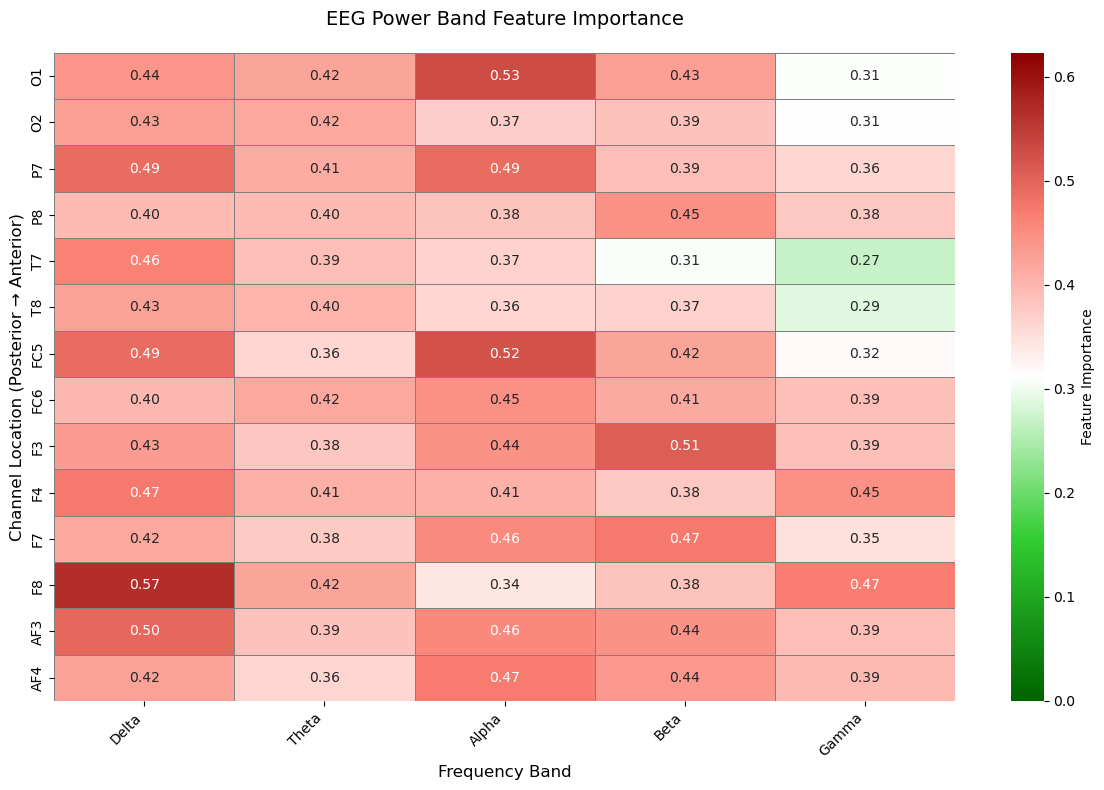

In [57]:
################q1
###### Making a heatmap version1: features for both classes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Load your data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\average_feature_importance_q1_y_original_with_channels.csv"
all_weights_df = pd.read_csv(weights_path)

# Filter for power features
power_features = all_weights_df[
    all_weights_df['Feature'].str.contains('Power') & 
    all_weights_df['Feature'].str.contains('Channel')
].copy()

# Extract channel and band information
def extract_components(feature_name):
    parts = feature_name.split(' - ')
    channel = parts[0].replace('Channel ', '')
    band = parts[1].replace(' Power', '')
    return channel, band

power_features[['Channel', 'Band']] = power_features['Feature'].apply(
    lambda x: pd.Series(extract_components(x)))

# Define proper ordering
channel_order = ['O1', 'O2', 'P7', 'P8', 'T7', 'T8', 
                'FC5', 'FC6', 'F3', 'F4', 'F7', 'F8', 'AF3', 'AF4']
band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Create pivot table
heatmap_df = power_features.groupby(['Channel', 'Band'])['Mean_Absolute_Weight'].mean().reset_index()
pivot_df = heatmap_df.pivot(index='Channel', columns='Band', values='Mean_Absolute_Weight')
pivot_df = pivot_df.reindex(index=channel_order, columns=band_order)

# Create vibrant colormap
colors = ["darkgreen", "limegreen", "white", "salmon", "darkred"]
cmap = LinearSegmentedColormap.from_list("vibrant", colors, N=256)

# Create figure with white background
plt.figure(figsize=(12, 8), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot heatmap with colors
sns.heatmap(
    pivot_df,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Feature Importance'},
    vmin=0,
    vmax=pivot_df.max().max() * 1.1  # Slightly above max value
)

# Formatting
plt.title('EEG Power Band Feature Importance', pad=20, fontsize=14)
plt.xlabel('Frequency Band', fontsize=12)
plt.ylabel('Channel Location (Posterior → Anterior)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save and show
output_path = os.path.join(output_dir, "power_features_heatmap_colored.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Heatmap with colors saved to: {output_path}")
plt.show()

Heatmap with colors saved to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\power_features_heatmap_colored.png


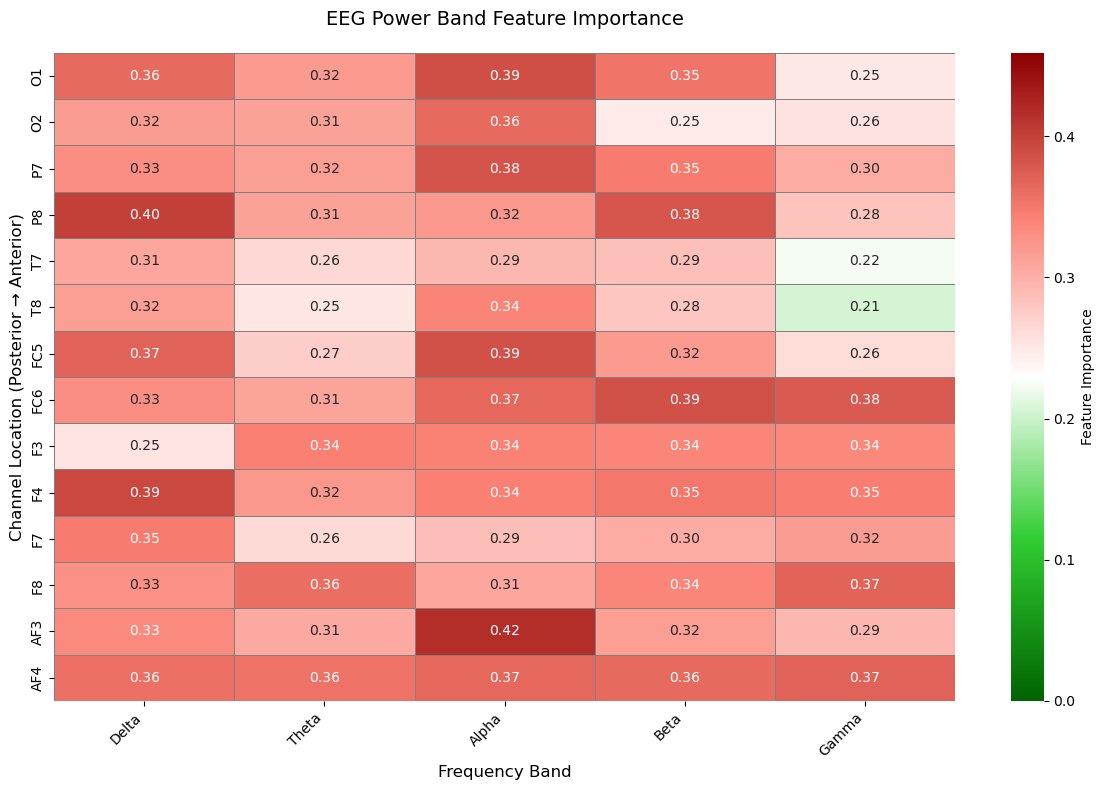

In [13]:
################ q3
###### Making a heatmap version1: features for both classes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Load your data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\average_feature_importance_q3_y_original_with_channels.csv"
all_weights_df = pd.read_csv(weights_path)

# Filter for power features
power_features = all_weights_df[
    all_weights_df['Feature'].str.contains('Power') & 
    all_weights_df['Feature'].str.contains('Channel')
].copy()

# Extract channel and band information
def extract_components(feature_name):
    parts = feature_name.split(' - ')
    channel = parts[0].replace('Channel ', '')
    band = parts[1].replace(' Power', '')
    return channel, band

power_features[['Channel', 'Band']] = power_features['Feature'].apply(
    lambda x: pd.Series(extract_components(x)))

# Define proper ordering
channel_order = ['O1', 'O2', 'P7', 'P8', 'T7', 'T8', 
                'FC5', 'FC6', 'F3', 'F4', 'F7', 'F8', 'AF3', 'AF4']
band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Create pivot table
heatmap_df = power_features.groupby(['Channel', 'Band'])['Mean_Absolute_Weight'].mean().reset_index()
pivot_df = heatmap_df.pivot(index='Channel', columns='Band', values='Mean_Absolute_Weight')
pivot_df = pivot_df.reindex(index=channel_order, columns=band_order)

# Create vibrant colormap
colors = ["darkgreen", "limegreen", "white", "salmon", "darkred"]
cmap = LinearSegmentedColormap.from_list("vibrant", colors, N=256)

# Create figure with white background
plt.figure(figsize=(12, 8), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot heatmap with colors
sns.heatmap(
    pivot_df,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Feature Importance'},
    vmin=0,
    vmax=pivot_df.max().max() * 1.1  # Slightly above max value
)

# Formatting
plt.title('EEG Power Band Feature Importance', pad=20, fontsize=14)
plt.xlabel('Frequency Band', fontsize=12)
plt.ylabel('Channel Location (Posterior → Anterior)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save and show
output_path = os.path.join(output_dir, "power_features_heatmap_colored.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Heatmap with colors saved to: {output_path}")
plt.show()

In [59]:
###### q1
############### weights analysis version 2: class 0 and class 1 seperately
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

# Channel number to location mapping
channel_mapping = {
    1: 'AF3', 2: 'F7', 3: 'F3', 4: 'FC5', 5: 'T7',
    6: 'P7', 7: 'O1', 8: 'O2', 9: 'P8', 10: 'T8',
    11: 'FC6', 12: 'F4', 13: 'F8', 14: 'AF4'
}

def convert_feature_names(feature_name):
    """Convert feature names containing channel numbers to channel locations"""
    # Find all numbers in the feature name
    numbers = re.findall(r'\d+', feature_name)
    
    for num in numbers:
        channel_num = int(num)
        if channel_num in channel_mapping:
            # Replace the number with the channel location
            feature_name = feature_name.replace(num, channel_mapping[channel_num])
    
    return feature_name

# Define the path to your weights data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\feature_weights_q1_y_original.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load and convert feature names as before
weights_df = pd.read_csv(weights_path)
weights_df['Feature'] = weights_df['Feature'].apply(convert_feature_names)

# Calculate statistics with class direction interpretation
feature_importance = weights_df.groupby('Feature').agg({
    'Absolute_Weight': ['mean', 'std'],
    'Weight': ['mean', 'std', 'count'],
}).reset_index()

# Flatten columns
feature_importance.columns = [
    'Feature', 
    'Mean_Absolute_Weight', 'Std_Absolute_Weight',
    'Mean_Weight', 'Std_Weight', 'Participant_Count'
]

# Add class interpretation columns
feature_importance['Direction'] = feature_importance['Mean_Weight'].apply(
    lambda x: 'Emotional (Class 1)' if x > 0 else 'Neutral (Class 0)'
)
feature_importance['Effect_Size'] = feature_importance['Mean_Absolute_Weight']

# Sort by importance
feature_importance = feature_importance.sort_values('Mean_Absolute_Weight', ascending=False)

# Print formatted table
print("\nFeature Weights by Class Contribution:")
print(feature_importance[['Feature', 'Mean_Weight', 'Direction', 'Effect_Size']].to_string(index=False))

# Save full results
output_path = os.path.join(output_dir, "feature_weights_with_class_interpretation.csv")
feature_importance.to_csv(output_path, index=False)
print(f"\nResults saved to {output_path}")

# Enhanced visualization
plt.figure(figsize=(14, 10))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)

# Color by direction
colors = ['red' if x > 0 else 'green' for x in top_features['Mean_Weight']]

plt.barh(top_features['Feature'], top_features['Mean_Absolute_Weight'],
         color=colors, alpha=0.7,
         xerr=top_features['Std_Absolute_Weight'],
         capsize=5, edgecolor='black')

# Add annotations
for i, (_, row) in enumerate(top_features.iterrows()):
    plt.text(0.05, i, 
             f"{'↑Emo' if row['Mean_Weight'] > 0 else '↓Neu'} ({row['Mean_Weight']:.2f})",
             va='center', ha='left', color='white', fontweight='bold')

plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Predictive Features\n(Red=Emotional, Green=Neutral)', pad=20)
plt.xlabel('Mean Absolute Weight (Effect Size)')
plt.ylabel('EEG Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = os.path.join(output_dir, "feature_weights_class_direction.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Directional plot saved to {plot_path}")
plt.close()


Feature Weights by Class Contribution:
                    Feature  Mean_Weight           Direction  Effect_Size
   Channel F8 - Delta Power     0.135658 Emotional (Class 1)     0.566581
Channel FC6 - theta Entropy     0.131741 Emotional (Class 1)     0.535243
   Channel O1 - Alpha Power     0.034098 Emotional (Class 1)     0.528557
 Channel F7 - theta Entropy    -0.066035   Neutral (Class 0)     0.522127
  Channel FC5 - Alpha Power    -0.137187   Neutral (Class 0)     0.521226
Channel AF3 - theta Entropy    -0.099295   Neutral (Class 0)     0.519163
    Channel F3 - Beta Power    -0.086286   Neutral (Class 0)     0.508749
  Channel AF3 - Delta Power     0.028784 Emotional (Class 1)     0.495647
 Channel F4 - alpha Entropy    -0.064492   Neutral (Class 0)     0.492279
   Channel P7 - Delta Power    -0.052406   Neutral (Class 0)     0.491039
   Channel P7 - Alpha Power    -0.165310   Neutral (Class 0)     0.490429
  Channel FC5 - Delta Power    -0.104780   Neutral (Class 0)     0.49012

In [15]:
###### q3
############### weights analysis version 2: class 0 and class 1 seperately
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

# Channel number to location mapping
channel_mapping = {
    1: 'AF3', 2: 'F7', 3: 'F3', 4: 'FC5', 5: 'T7',
    6: 'P7', 7: 'O1', 8: 'O2', 9: 'P8', 10: 'T8',
    11: 'FC6', 12: 'F4', 13: 'F8', 14: 'AF4'
}

def convert_feature_names(feature_name):
    """Convert feature names containing channel numbers to channel locations"""
    # Find all numbers in the feature name
    numbers = re.findall(r'\d+', feature_name)
    
    for num in numbers:
        channel_num = int(num)
        if channel_num in channel_mapping:
            # Replace the number with the channel location
            feature_name = feature_name.replace(num, channel_mapping[channel_num])
    
    return feature_name

# Define the path to your weights data
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\feature_weights_q3_y_original.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load and convert feature names as before
weights_df = pd.read_csv(weights_path)
weights_df['Feature'] = weights_df['Feature'].apply(convert_feature_names)

# Calculate statistics with class direction interpretation
feature_importance = weights_df.groupby('Feature').agg({
    'Absolute_Weight': ['mean', 'std'],
    'Weight': ['mean', 'std', 'count'],
}).reset_index()

# Flatten columns
feature_importance.columns = [
    'Feature', 
    'Mean_Absolute_Weight', 'Std_Absolute_Weight',
    'Mean_Weight', 'Std_Weight', 'Participant_Count'
]

# Add class interpretation columns
feature_importance['Direction'] = feature_importance['Mean_Weight'].apply(
    lambda x: 'Emotional (Class 1)' if x > 0 else 'Neutral (Class 0)'
)
feature_importance['Effect_Size'] = feature_importance['Mean_Absolute_Weight']

# Sort by importance
feature_importance = feature_importance.sort_values('Mean_Absolute_Weight', ascending=False)

# Print formatted table
print("\nFeature Weights by Class Contribution:")
print(feature_importance[['Feature', 'Mean_Weight', 'Direction', 'Effect_Size']].to_string(index=False))

# Save full results
output_path = os.path.join(output_dir, "feature_weights_with_class_interpretation.csv")
feature_importance.to_csv(output_path, index=False)
print(f"\nResults saved to {output_path}")

# Enhanced visualization
plt.figure(figsize=(14, 10))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)

# Color by direction
colors = ['red' if x > 0 else 'green' for x in top_features['Mean_Weight']]

plt.barh(top_features['Feature'], top_features['Mean_Absolute_Weight'],
         color=colors, alpha=0.7,
         xerr=top_features['Std_Absolute_Weight'],
         capsize=5, edgecolor='black')

# Add annotations
for i, (_, row) in enumerate(top_features.iterrows()):
    plt.text(0.05, i, 
             f"{'↑Emo' if row['Mean_Weight'] > 0 else '↓Neu'} ({row['Mean_Weight']:.2f})",
             va='center', ha='left', color='white', fontweight='bold')

plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Predictive Features\n(Red=Emotional, Green=Neutral)', pad=20)
plt.xlabel('Mean Absolute Weight (Effect Size)')
plt.ylabel('EEG Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = os.path.join(output_dir, "feature_weights_class_direction.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Directional plot saved to {plot_path}")
plt.close()


Feature Weights by Class Contribution:
                    Feature  Mean_Weight           Direction  Effect_Size
 Channel F8 - theta Entropy    -0.038158   Neutral (Class 0)     0.430408
Channel FC6 - theta Entropy     0.062291 Emotional (Class 1)     0.420389
  Channel AF3 - Alpha Power     0.050946 Emotional (Class 1)     0.417367
   Channel P8 - Delta Power     0.027781 Emotional (Class 1)     0.399963
Channel AF4 - theta Entropy    -0.000131   Neutral (Class 0)     0.395434
   Channel F4 - Delta Power     0.073889 Emotional (Class 1)     0.393413
 Channel F3 - theta Entropy    -0.018875   Neutral (Class 0)     0.391549
   Channel O1 - Alpha Power    -0.028114   Neutral (Class 0)     0.388581
   Channel FC6 - Beta Power     0.013557 Emotional (Class 1)     0.386911
  Channel FC5 - Alpha Power    -0.058427   Neutral (Class 0)     0.386297
 Channel P8 - theta Entropy     0.001356 Emotional (Class 1)     0.385286
   Channel P7 - Alpha Power    -0.058537   Neutral (Class 0)     0.38311

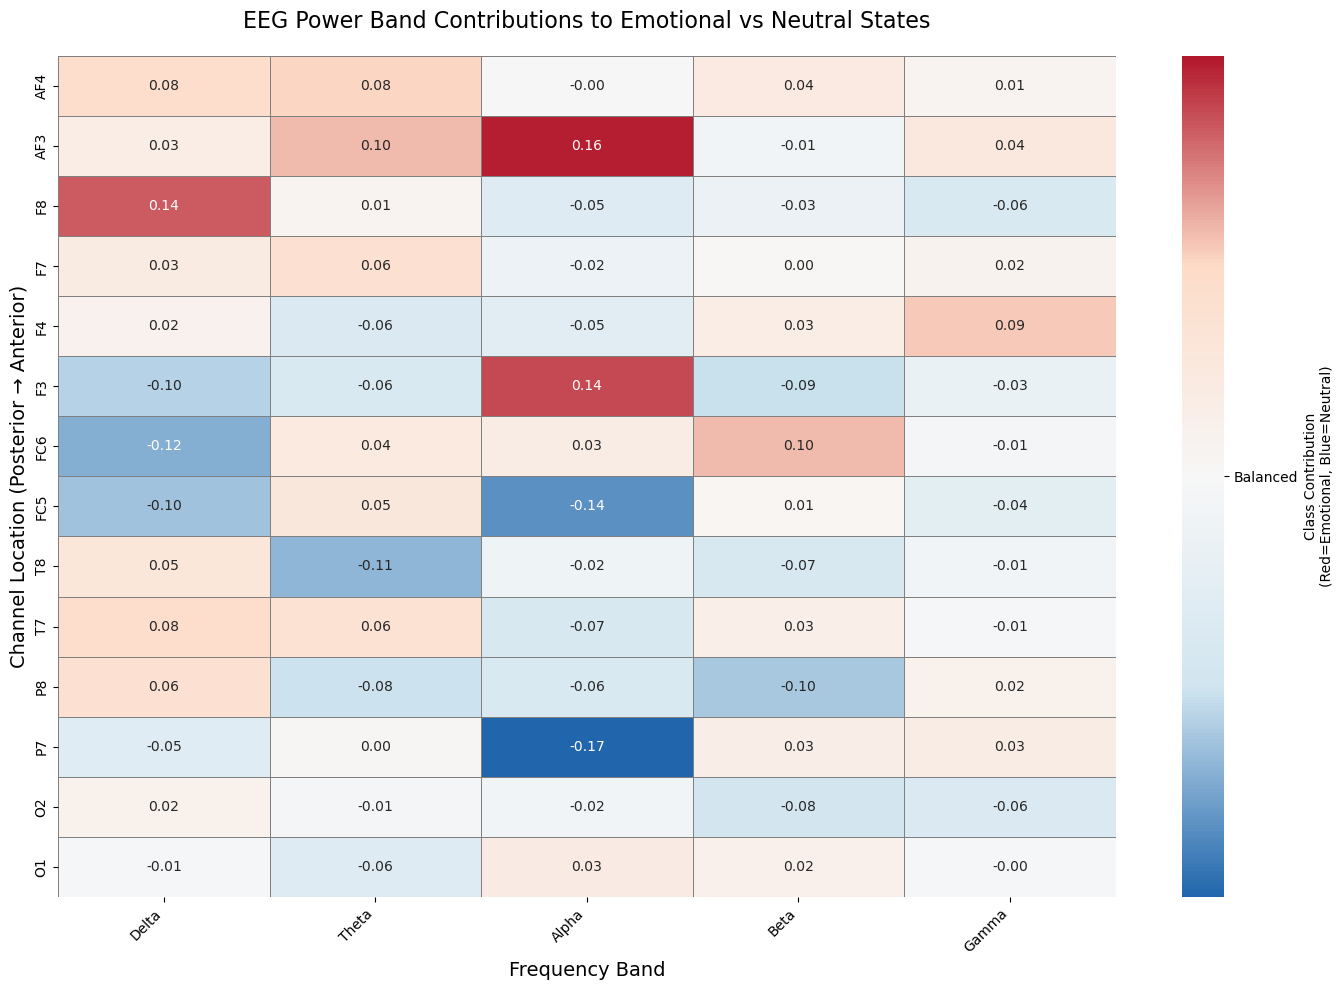

In [61]:
###### Making a heatmap version1: features for both classes, q1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

############### weights analysis version 2: heatmap 
# Load your data - now including Mean_Weight for direction
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\average_feature_importance_q1_y_original_with_channels.csv"
all_weights_df = pd.read_csv(weights_path)

# Filter power features
power_features = all_weights_df[
    all_weights_df['Feature'].str.contains('Power') & 
    all_weights_df['Feature'].str.contains('Channel')
].copy()

# Extract components
def extract_components(feature_name):
    parts = feature_name.split(' - ')
    channel = parts[0].replace('Channel ', '')
    band = parts[1].replace(' Power', '')
    return channel, band

power_features[['Channel', 'Band']] = power_features['Feature'].apply(lambda x: pd.Series(extract_components(x)))

# Neuroanatomical channel order (anterior → posterior)
channel_order = ['AF4', 'AF3', 'F8', 'F7', 'F4', 'F3', 'FC6', 'FC5', 'T8', 'T7', 'P8', 'P7', 'O2', 'O1']
band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Create pivot table for SIGNED weights (direction matters)
pivot_df = power_features.pivot_table(
    index='Channel',
    columns='Band',
    values='Mean_Weight',  # Using signed weights for color direction
    aggfunc='mean'
).reindex(index=channel_order, columns=band_order)

# Enhanced colormap
colors = ["#2166ac", "#d1e5f0", "#f7f7f7", "#fddbc7", "#b2182b"]  # Strong blue to white to strong red
cmap = LinearSegmentedColormap.from_list("diverging", colors, N=256)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    pivot_df,
    cmap=cmap,
    center=0,  # Critical for diverging colormap
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={
        'label': 'Class Contribution\n(Red=Emotional, Blue=Neutral)', 
        'ticks': [-1, -0.5, 0, 0.5, 1]  # Adjust based on your weight range
    },
    vmin=-max(abs(pivot_df.min().min()), pivot_df.max().max()),
    vmax=max(abs(pivot_df.min().min()), pivot_df.max().max())
)

# Formatting
plt.title('EEG Power Band Contributions to Emotional vs Neutral States', pad=20, fontsize=16)
plt.xlabel('Frequency Band', fontsize=14)
plt.ylabel('Channel Location (Posterior → Anterior)', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add colorbar interpretation
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(['Strong Neutral', 'Neutral', 'Balanced', 'Emotional', 'Strong Emotional'])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "emotion_neutral_contributions.png"), dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'output_dir' is not defined

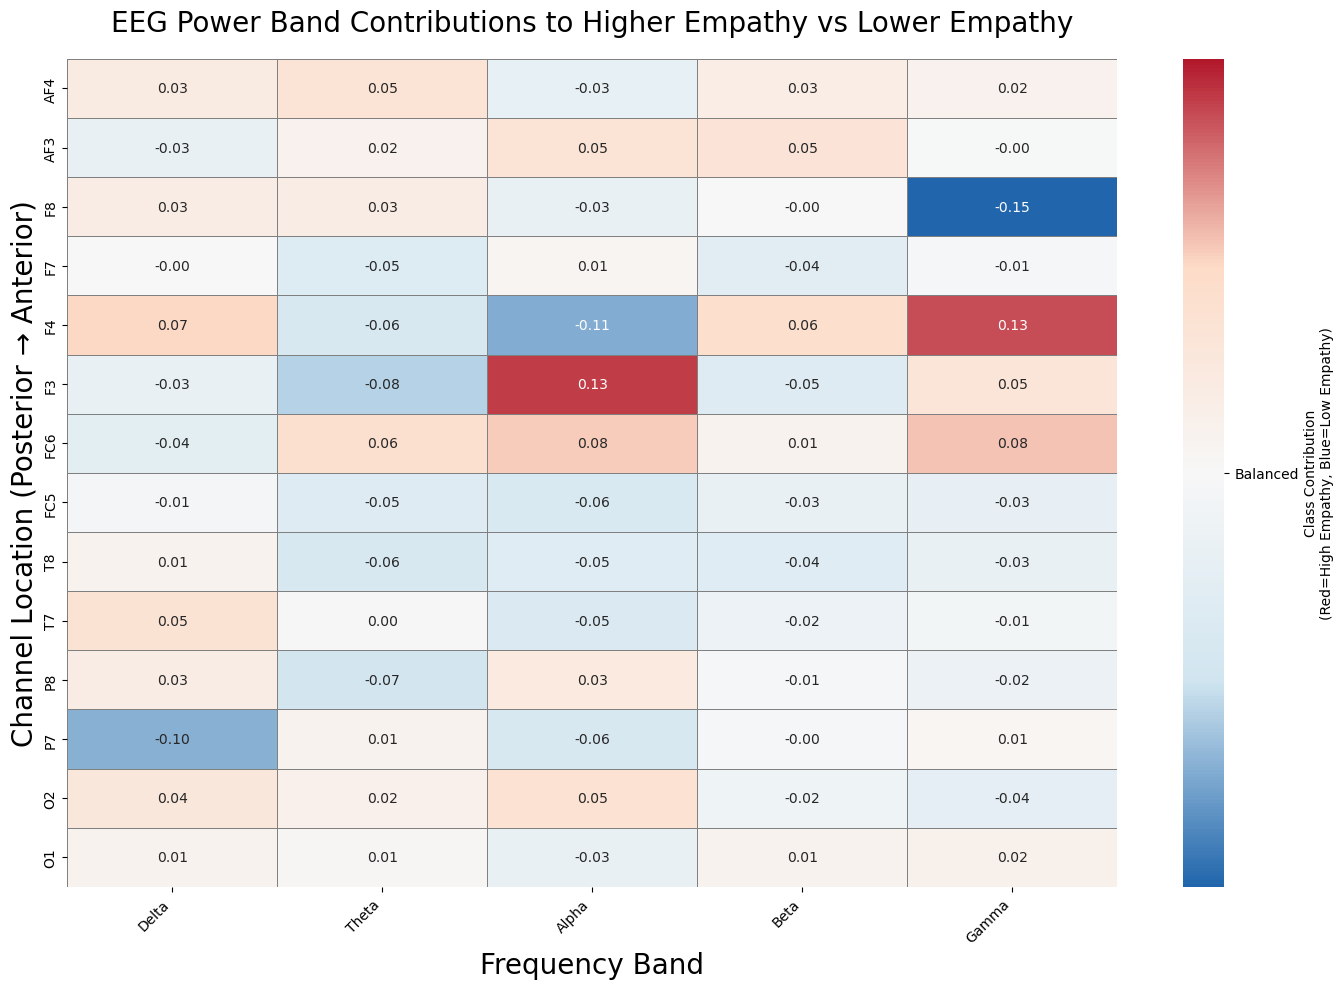

In [6]:
###### Making a heatmap version1: features for both classes, q3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

############### weights analysis version 2: heatmap 
# Load your data - now including Mean_Weight for direction
weights_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\average_feature_importance_q3_y_original_with_channels.csv"
all_weights_df = pd.read_csv(weights_path)

# Filter power features
power_features = all_weights_df[
    all_weights_df['Feature'].str.contains('Power') & 
    all_weights_df['Feature'].str.contains('Channel')
].copy()

# Extract components
def extract_components(feature_name):
    parts = feature_name.split(' - ')
    channel = parts[0].replace('Channel ', '')
    band = parts[1].replace(' Power', '')
    return channel, band

power_features[['Channel', 'Band']] = power_features['Feature'].apply(lambda x: pd.Series(extract_components(x)))

# Neuroanatomical channel order (anterior → posterior)
channel_order = ['AF4', 'AF3', 'F8', 'F7', 'F4', 'F3', 'FC6', 'FC5', 'T8', 'T7', 'P8', 'P7', 'O2', 'O1']
band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

# Create pivot table for SIGNED weights (direction matters)
pivot_df = power_features.pivot_table(
    index='Channel',
    columns='Band',
    values='Mean_Weight',  # Using signed weights for color direction
    aggfunc='mean'
).reindex(index=channel_order, columns=band_order)

# Enhanced colormap
colors = ["#2166ac", "#d1e5f0", "#f7f7f7", "#fddbc7", "#b2182b"]  # Strong blue to white to strong red
cmap = LinearSegmentedColormap.from_list("diverging", colors, N=256)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    pivot_df,
    cmap=cmap,
    center=0,  # Critical for diverging colormap
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={
        'label': 'Class Contribution\n(Red=High Empathy, Blue=Low Empathy)', 
        'ticks': [-1, -0.5, 0, 0.5, 1]  # Adjust based on your weight range
    },
    vmin=-max(abs(pivot_df.min().min()), pivot_df.max().max()),
    vmax=max(abs(pivot_df.min().min()), pivot_df.max().max())
)

# Formatting
plt.title('EEG Power Band Contributions to Higher Empathy vs Lower Empathy', pad=20, fontsize=20)
plt.xlabel('Frequency Band', fontsize=20)
plt.ylabel('Channel Location (Posterior → Anterior)', fontsize=20)
plt.xticks(rotation=45, ha='right')

# Add colorbar interpretation
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(['Strong Neutral', 'Neutral', 'Balanced', 'Emotional', 'Strong Emotional'])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "emotion_neutral_contributions.png"), dpi=300, bbox_inches='tight')
plt.show()

Descriptive Statistics:
Original Data (F1):
count    70.000000
mean      0.804644
std       0.049812
min       0.703930
25%       0.772835
50%       0.800619
75%       0.833373
max       0.919098
Name: CV_F1_Mean, dtype: float64

Permuted Data (F1):
count    70.000000
mean      0.481477
std       0.113884
min       0.242033
25%       0.408959
50%       0.470476
75%       0.552019
max       0.790404
Name: CV_F1_Mean, dtype: float64

Original Data (Accuracy):
count    70.000000
mean      0.815471
std       0.034857
min       0.740089
25%       0.791722
50%       0.810659
75%       0.833347
max       0.901495
Name: CV_Accuracy_Mean, dtype: float64

Permuted Data (Accuracy):
count    70.000000
mean      0.515526
std       0.045559
min       0.415116
25%       0.490116
50%       0.508250
75%       0.533873
max       0.678738
Name: CV_Accuracy_Mean, dtype: float64

Normality Test (Shapiro-Wilk):
F1 Original: W=0.9863, p=0.6460
F1 Permuted: W=0.9878, p=0.7352
Accuracy Original: W=0.9858, p=0.

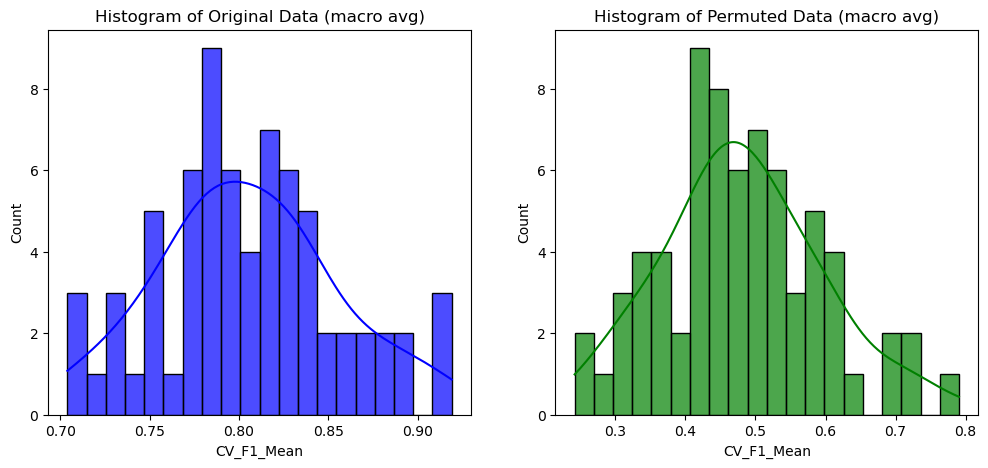

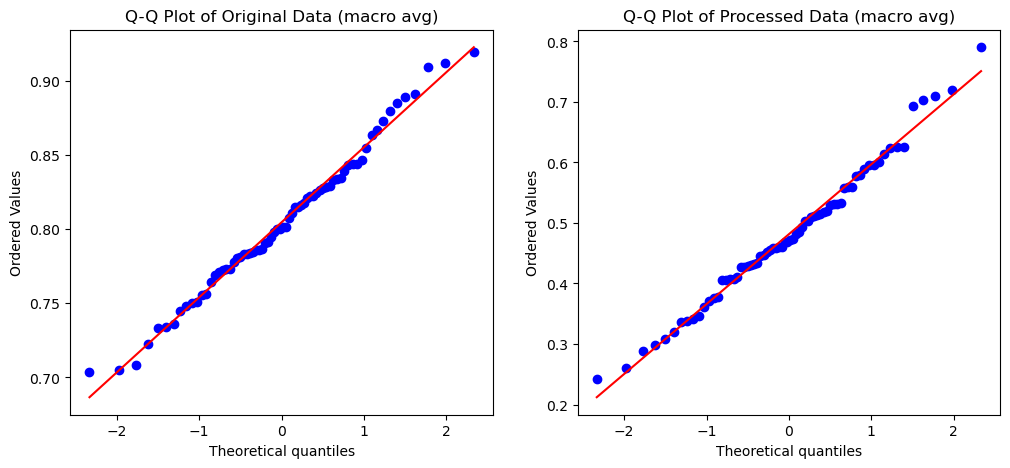

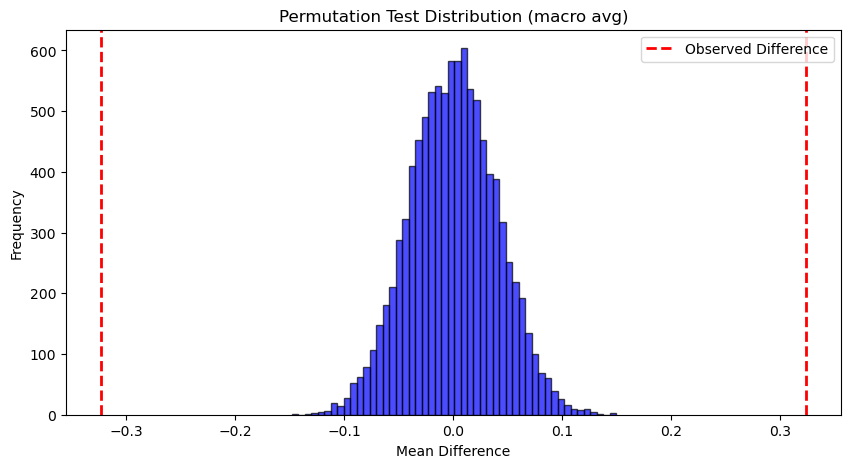

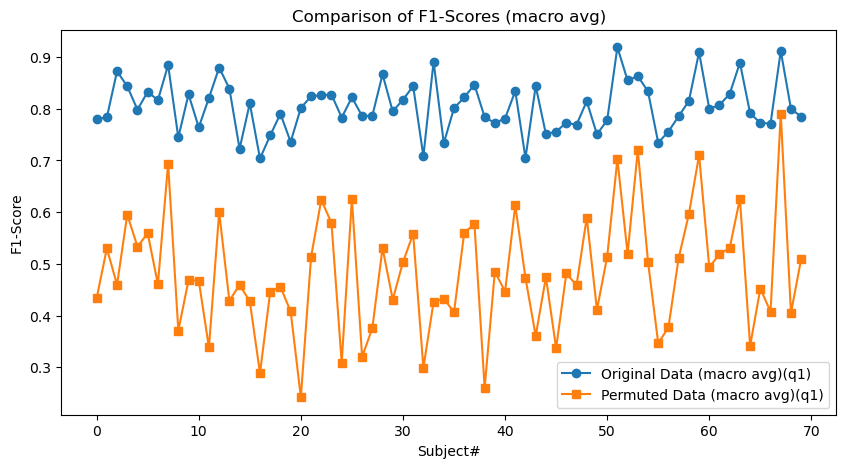

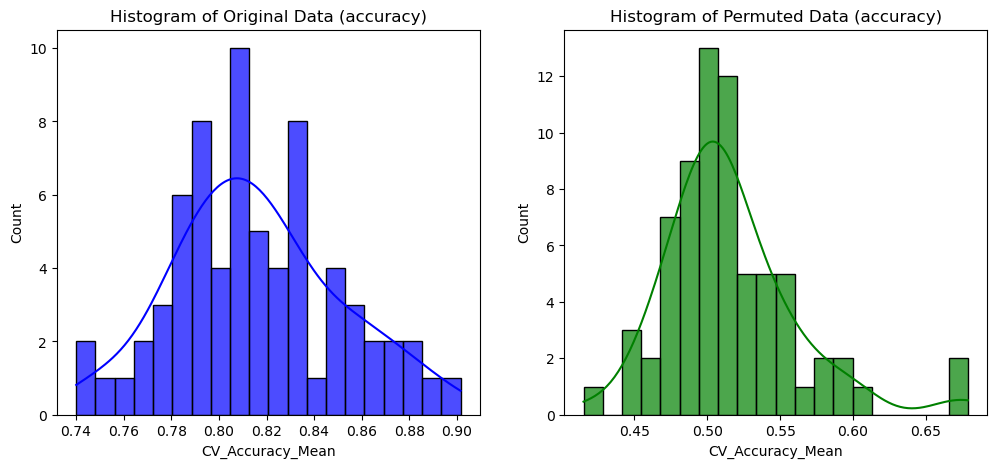

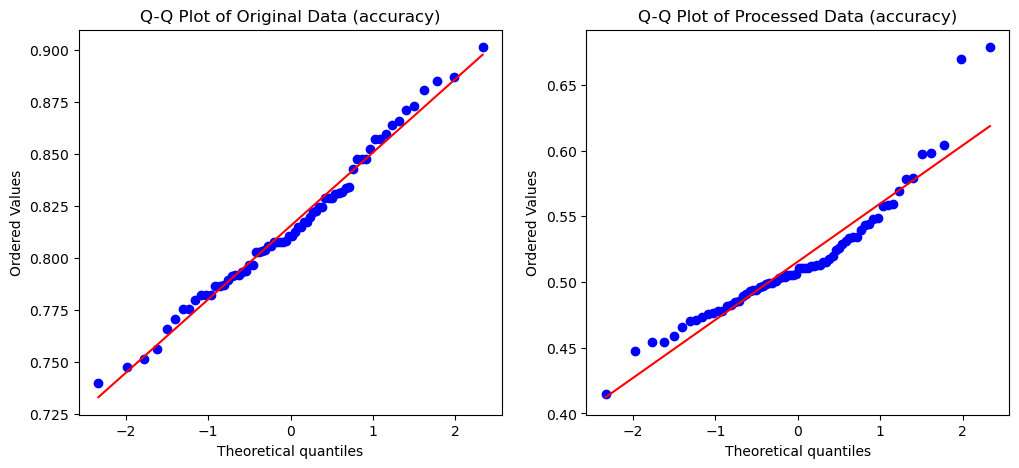

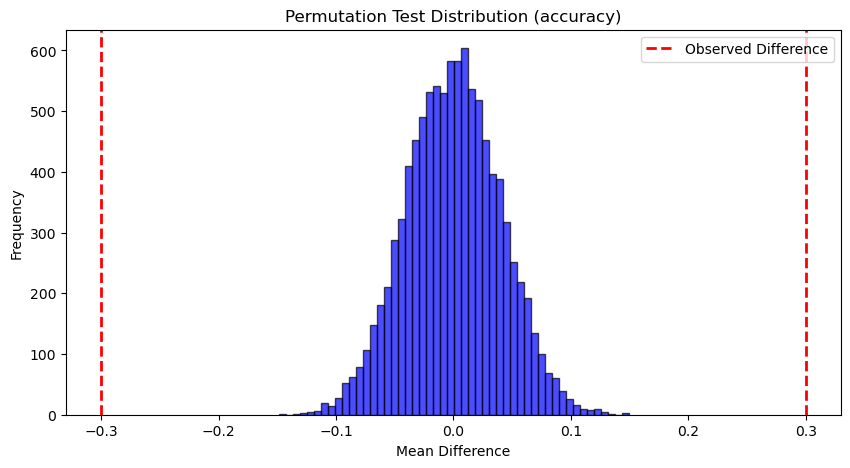

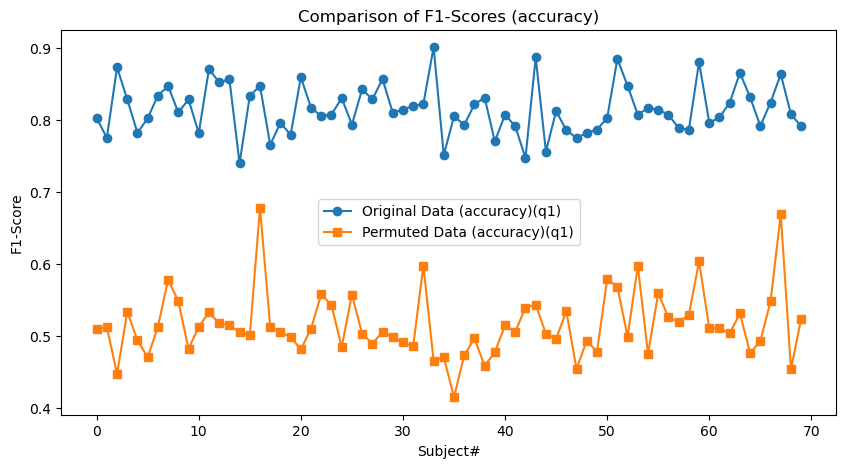

In [4]:
########## Additional LOSO test
############ Quick t-test and permutation test
########### Q1 ###############
## Notes: no weird outliers in ratings like other conditions
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# File paths
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\cv_metrics_q1_y_original.csv"
file_permuted = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\cv_metrics_q1_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from filename
filename = os.path.basename(file_original)
condition_name = None
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break
if not condition_name:
    raise ValueError("Could not extract condition name from filename.")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Column names
f1_col = "CV_F1_Mean"
acc_col = "CV_Accuracy_Mean"

# Clean up F1 values (remove parentheses and convert to float)
df1[f1_col] = df1[f1_col].astype(str).str.extract(r'([\d\.]+)').astype(float)
df2[f1_col] = df2[f1_col].astype(str).str.extract(r'([\d\.]+)').astype(float)

# Drop NaNs
f1_scores_1 = df1[f1_col].dropna()
f1_scores_2 = df2[f1_col].dropna()
acc_scores_1 = df1[acc_col].dropna()
acc_scores_2 = df2[acc_col].dropna()

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (F1):")
print(f1_scores_1.describe())
print("\nPermuted Data (F1):")
print(f1_scores_2.describe())
print("\nOriginal Data (Accuracy):")
print(acc_scores_1.describe())
print("\nPermuted Data (Accuracy):")
print(acc_scores_2.describe())

# Normality test (Shapiro-Wilk)
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk):")
print(f"F1 Original: W={stat1:.4f}, p={p1:.4f}")
print(f"F1 Permuted: W={stat2:.4f}, p={p2:.4f}")
print(f"Accuracy Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Accuracy Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Paired t-tests
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

# Cohen's d for paired samples
def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    return np.mean(diff) / np.std(diff, ddof=1)

d_f1 = cohens_d_paired(f1_scores_1, f1_scores_2)
d_acc = cohens_d_paired(acc_scores_1, acc_scores_2)

print(f"\nF1 Scores - t-stat: {t_stat:.3f}, p: {p_value:.3f}, d: {d_f1:.3f}")
print(f"Accuracy - t-stat: {t_acc:.3f}, p: {p_acc:.3f}, d: {d_acc:.3f}")

# Save to file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results for F1:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    f.write(f"Cohen's d: {d_f1:.4f}\n")
    f.write("Result: " + ("Significant\n" if p_value < 0.05 else "Not Significant\n"))

    f.write("\nPaired t-test results for Accuracy:\n")
    f.write(f"T-statistic: {t_acc:.4f}\n")
    f.write(f"P-value: {p_acc:.4f}\n")
    f.write(f"Cohen's d: {d_acc:.4f}\n")
    f.write("Result: " + ("Significant\n" if p_acc < 0.05 else "Not Significant\n"))

# Permutation test
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

np.random.seed(42)
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)
observed_diff_acc = np.mean(acc_scores_1 - acc_scores_2)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)
perm_diffs_acc = permute_test(acc_scores_1, acc_scores_2, num_permutations)

perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
perm_p_value_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(observed_diff_acc))

print("\nPermutation Test Results:")
print(f"F1 Observed Diff: {observed_diff:.4f}, p-value: {perm_p_value:.4f}")
print(f"Accuracy Observed Diff: {observed_diff_acc:.4f}, p-value: {perm_p_value_acc:.4f}")

with open(output_file, "a") as f:
    f.write("\nPermutation Test Results for F1:\n")
    f.write(f"Observed Mean Diff: {observed_diff:.4f}\n")
    f.write(f"P-value: {perm_p_value:.4f}\n")
    f.write("Result: " + ("Significant\n" if perm_p_value < 0.05 else "Not Significant\n"))

    f.write("\nPermutation Test Results for Accuracy:\n")
    f.write(f"Observed Mean Diff: {observed_diff_acc:.4f}\n")
    f.write(f"P-value: {perm_p_value_acc:.4f}\n")
    f.write("Result: " + ("Significant\n" if perm_p_value_acc < 0.05 else "Not Significant\n"))
        
# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"loso_histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"loso_qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"loso_permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"loso_f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()

#################### Visualization for accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(acc_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (accuracy)")
plt.subplot(1, 2, 2)
sns.histplot(acc_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"loso_acc_histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(acc_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (accuracy)")
plt.subplot(1, 2, 2)
stats.probplot(acc_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"loso_accuracy_qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff_acc, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff_acc, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"loso_accuracy_permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(acc_scores_1.values, label=f'Original Data (accuracy)({condition_name})', marker='o')
plt.plot(acc_scores_2.values, label=f'Permuted Data (accuracy)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"loso_accuracy_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()

Descriptive Statistics:
Original Data (F1):
count    69.000000
mean      0.831670
std       0.093989
min       0.644023
25%       0.769770
50%       0.817231
75%       0.885225
max       1.000000
Name: CV_F1_Mean, dtype: float64

Permuted Data (F1):
count    69.000000
mean      0.497302
std       0.236904
min       0.000000
25%       0.369528
50%       0.503662
75%       0.628222
max       0.982011
Name: CV_F1_Mean, dtype: float64

Original Data (Accuracy):
count    69.000000
mean      0.857738
std       0.068302
min       0.740089
25%       0.812735
50%       0.838538
75%       0.887874
max       1.000000
Name: CV_Accuracy_Mean, dtype: float64

Permuted Data (Accuracy):
count    69.000000
mean      0.606814
std       0.131921
min       0.463455
25%       0.515116
50%       0.550388
75%       0.658195
max       0.965061
Name: CV_Accuracy_Mean, dtype: float64

Normality Test (Shapiro-Wilk):
F1 Original: W=0.9660, p=0.0569
F1 Permuted: W=0.9826, p=0.4518
Accuracy Original: W=0.8974, p=0.

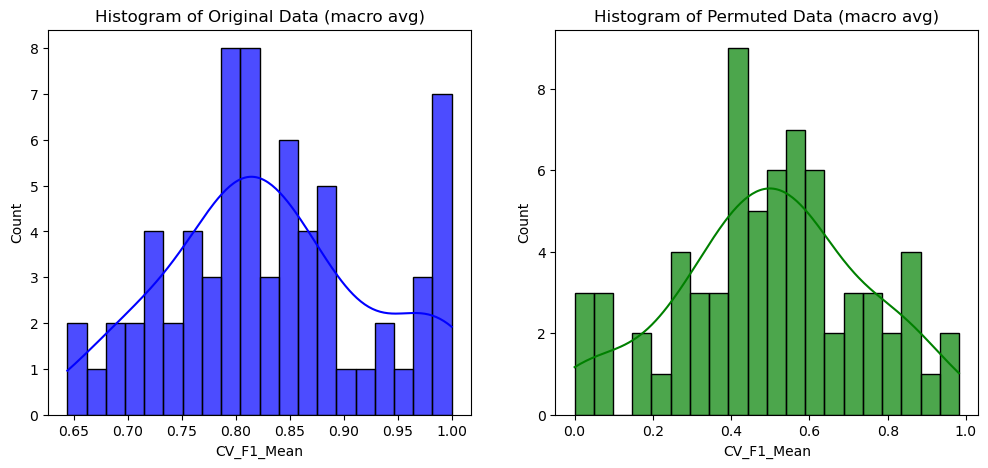

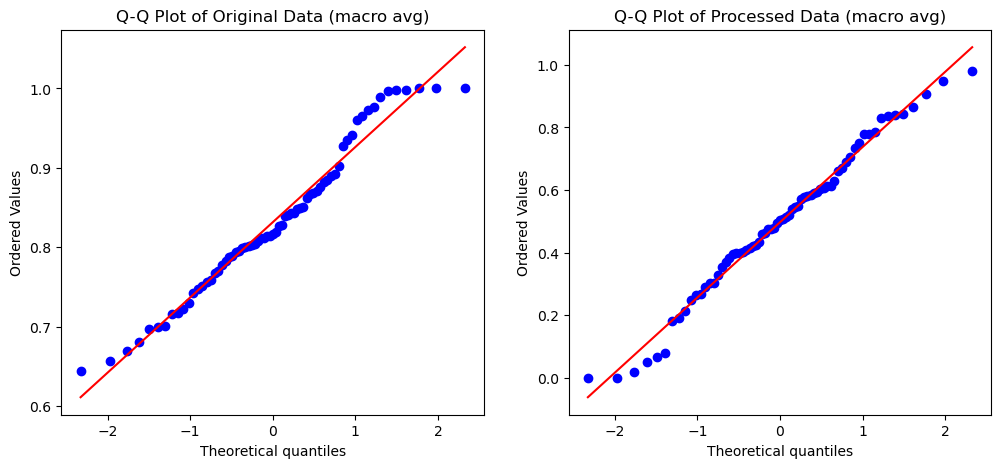

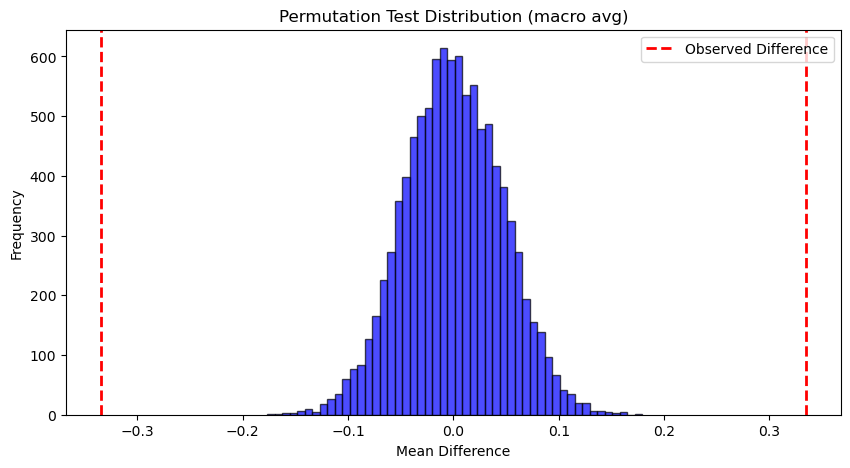

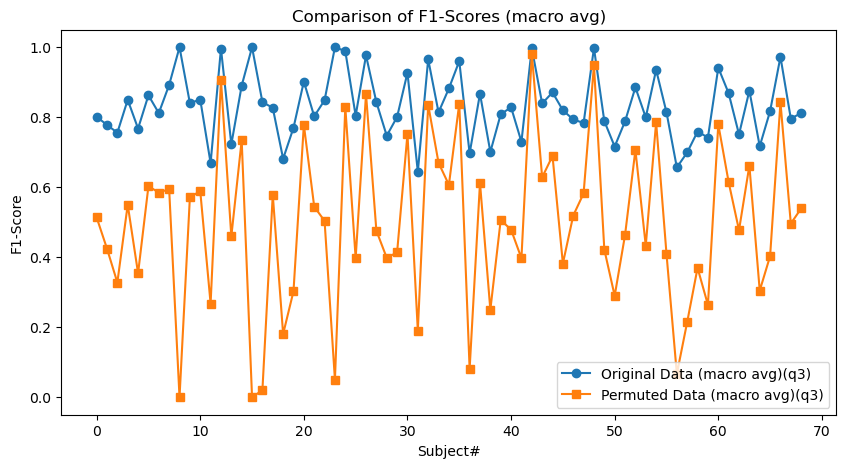

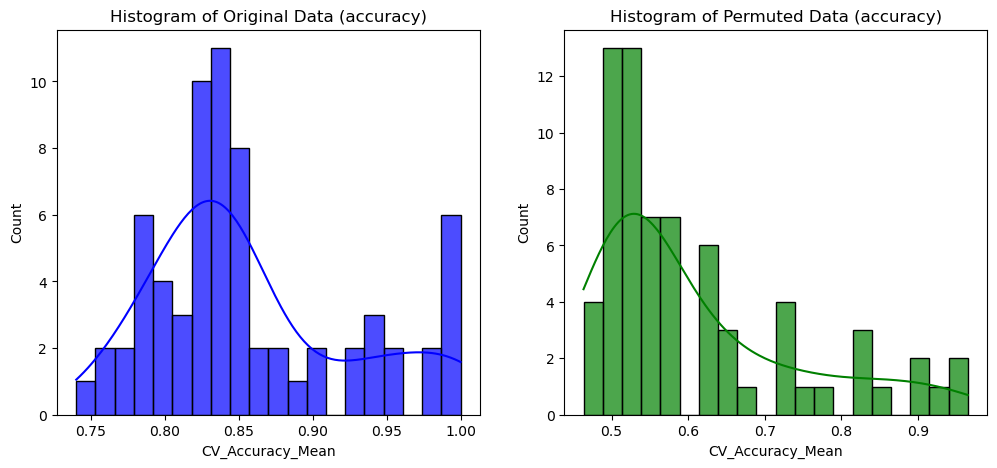

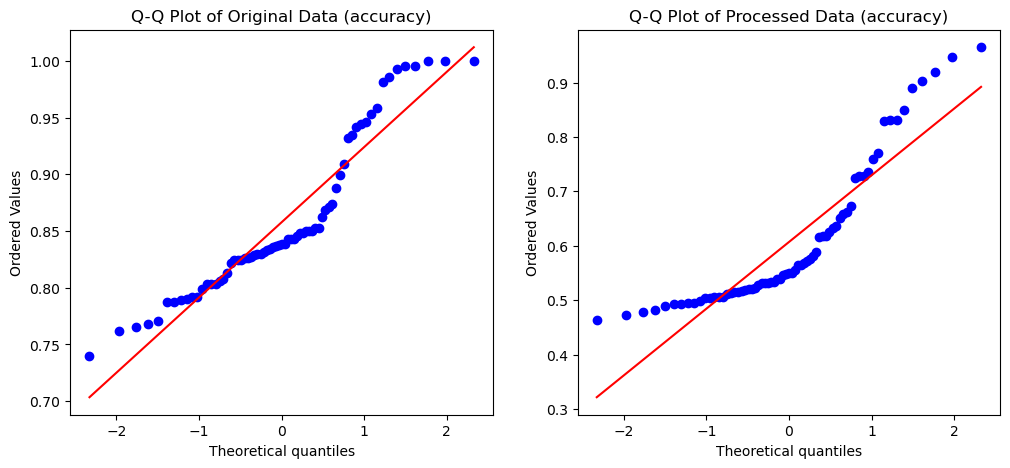

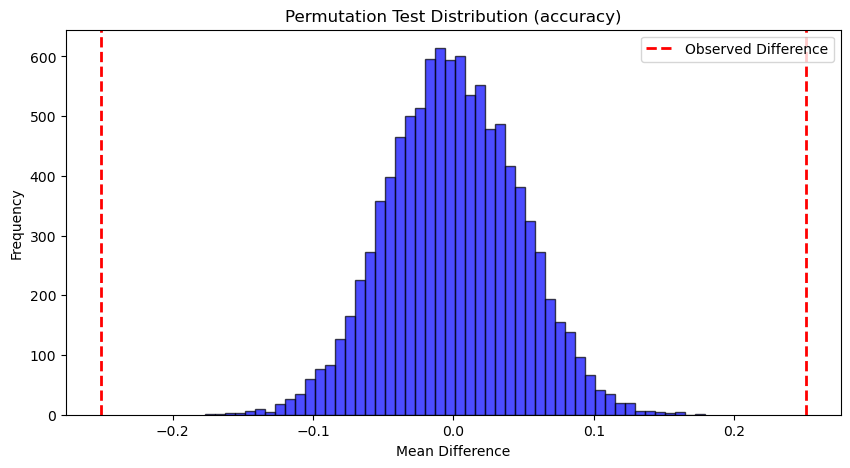

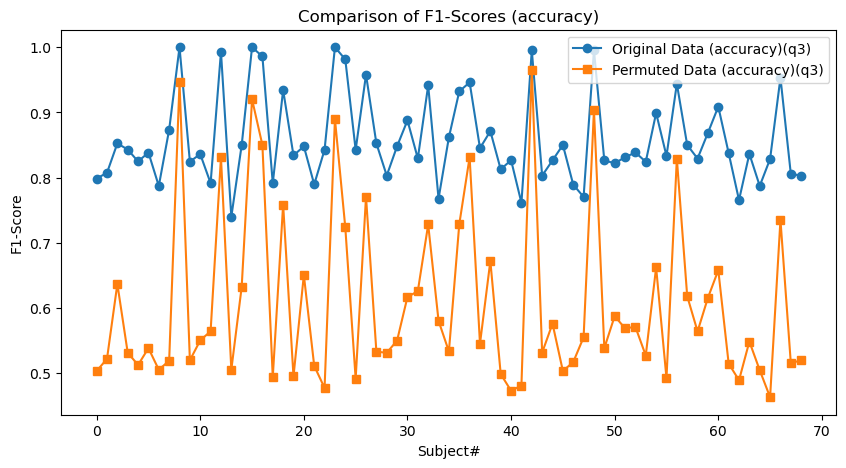

In [19]:
########## Additional LOSO test
############ Quick t-test and permutation test
########### Q3 ###############
## Notes: no weird outliers in ratings like other conditions
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# File paths
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\cv_metrics_q3_y_original.csv"
file_permuted = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\cv_metrics_q3_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from filename
filename = os.path.basename(file_original)
condition_name = None
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break
if not condition_name:
    raise ValueError("Could not extract condition name from filename.")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Column names
f1_col = "CV_F1_Mean"
acc_col = "CV_Accuracy_Mean"

# Clean up F1 values (remove parentheses and convert to float)
df1[f1_col] = df1[f1_col].astype(str).str.extract(r'([\d\.]+)').astype(float)
df2[f1_col] = df2[f1_col].astype(str).str.extract(r'([\d\.]+)').astype(float)

# Drop NaNs
f1_scores_1 = df1[f1_col].dropna()
f1_scores_2 = df2[f1_col].dropna()
acc_scores_1 = df1[acc_col].dropna()
acc_scores_2 = df2[acc_col].dropna()

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (F1):")
print(f1_scores_1.describe())
print("\nPermuted Data (F1):")
print(f1_scores_2.describe())
print("\nOriginal Data (Accuracy):")
print(acc_scores_1.describe())
print("\nPermuted Data (Accuracy):")
print(acc_scores_2.describe())

# Normality test (Shapiro-Wilk)
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk):")
print(f"F1 Original: W={stat1:.4f}, p={p1:.4f}")
print(f"F1 Permuted: W={stat2:.4f}, p={p2:.4f}")
print(f"Accuracy Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Accuracy Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Paired t-tests
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

# Cohen's d for paired samples
def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    return np.mean(diff) / np.std(diff, ddof=1)

d_f1 = cohens_d_paired(f1_scores_1, f1_scores_2)
d_acc = cohens_d_paired(acc_scores_1, acc_scores_2)

print(f"\nF1 Scores - t-stat: {t_stat:.3f}, p: {p_value:.3f}, d: {d_f1:.3f}")
print(f"Accuracy - t-stat: {t_acc:.3f}, p: {p_acc:.3f}, d: {d_acc:.3f}")

# Save to file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results for F1:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    f.write(f"Cohen's d: {d_f1:.4f}\n")
    f.write("Result: " + ("Significant\n" if p_value < 0.05 else "Not Significant\n"))

    f.write("\nPaired t-test results for Accuracy:\n")
    f.write(f"T-statistic: {t_acc:.4f}\n")
    f.write(f"P-value: {p_acc:.4f}\n")
    f.write(f"Cohen's d: {d_acc:.4f}\n")
    f.write("Result: " + ("Significant\n" if p_acc < 0.05 else "Not Significant\n"))

# Permutation test
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

np.random.seed(42)
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)
observed_diff_acc = np.mean(acc_scores_1 - acc_scores_2)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)
perm_diffs_acc = permute_test(acc_scores_1, acc_scores_2, num_permutations)

perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
perm_p_value_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(observed_diff_acc))

print("\nPermutation Test Results:")
print(f"F1 Observed Diff: {observed_diff:.4f}, p-value: {perm_p_value:.4f}")
print(f"Accuracy Observed Diff: {observed_diff_acc:.4f}, p-value: {perm_p_value_acc:.4f}")

with open(output_file, "a") as f:
    f.write("\nPermutation Test Results for F1:\n")
    f.write(f"Observed Mean Diff: {observed_diff:.4f}\n")
    f.write(f"P-value: {perm_p_value:.4f}\n")
    f.write("Result: " + ("Significant\n" if perm_p_value < 0.05 else "Not Significant\n"))

    f.write("\nPermutation Test Results for Accuracy:\n")
    f.write(f"Observed Mean Diff: {observed_diff_acc:.4f}\n")
    f.write(f"P-value: {perm_p_value_acc:.4f}\n")
    f.write("Result: " + ("Significant\n" if perm_p_value_acc < 0.05 else "Not Significant\n"))
        
# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"loso_histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"loso_qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"loso_permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"loso_f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()

#################### Visualization for accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(acc_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (accuracy)")
plt.subplot(1, 2, 2)
sns.histplot(acc_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"loso_acc_histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(acc_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (accuracy)")
plt.subplot(1, 2, 2)
stats.probplot(acc_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"loso_accuracy_qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff_acc, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff_acc, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"loso_accuracy_permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(acc_scores_1.values, label=f'Original Data (accuracy)({condition_name})', marker='o')
plt.plot(acc_scores_2.values, label=f'Permuted Data (accuracy)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"loso_accuracy_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()

Descriptive Statistics:
Original Data (macro avg):
count    70.000000
mean      0.818444
std       0.042884
min       0.690616
25%       0.792196
50%       0.819337
75%       0.849269
max       0.906469
Name: F1, dtype: float64

Permuted Data (macro avg):
count    70.000000
mean      0.500539
std       0.049114
min       0.383124
25%       0.473790
50%       0.498239
75%       0.531602
max       0.597990
Name: F1, dtype: float64

Accuracy (Class == 0) - Original:
count    70.000000
mean      0.825501
std       0.044458
min       0.691589
25%       0.794393
50%       0.822430
75%       0.850467
max       0.925234
Name: Accuracy, dtype: float64

Accuracy (Class == 0) - Permuted:
count    70.000000
mean      0.527637
std       0.063280
min       0.383178
25%       0.495327
50%       0.523364
75%       0.560748
max       0.728972
Name: Accuracy, dtype: float64

Normality Test (Shapiro-Wilk Test):
Original Data: W=0.9893, p=0.8159
Permuted Data: W=0.9773, p=0.2325
Acc Original: W=0.9852, p=

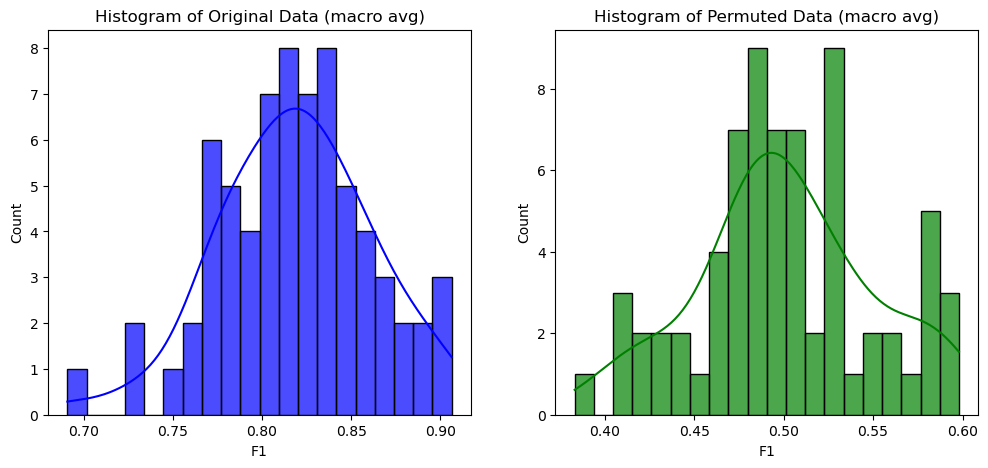

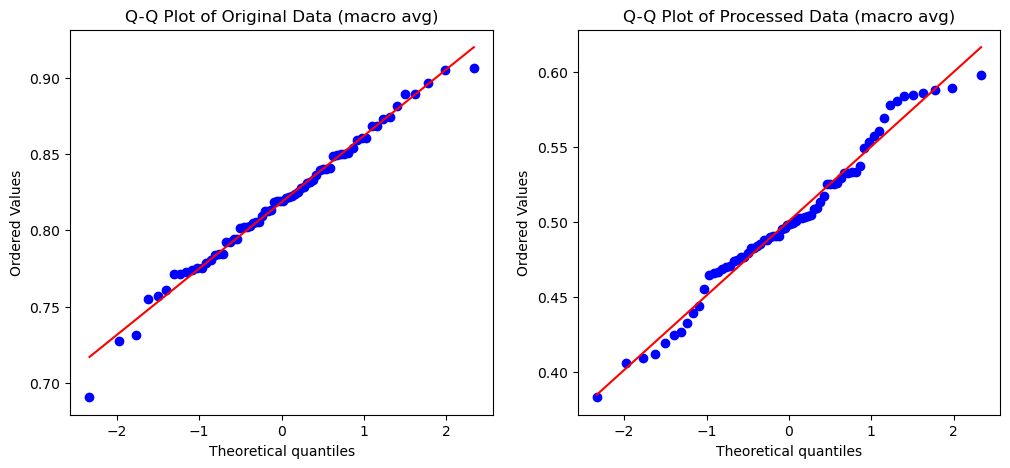

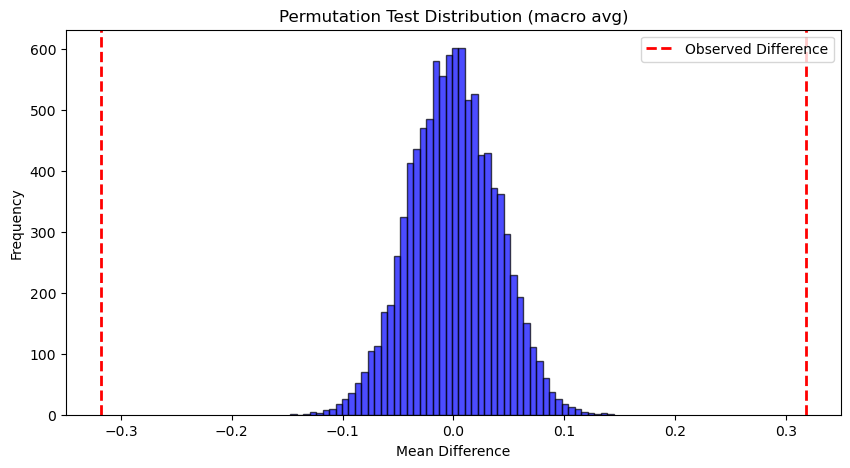

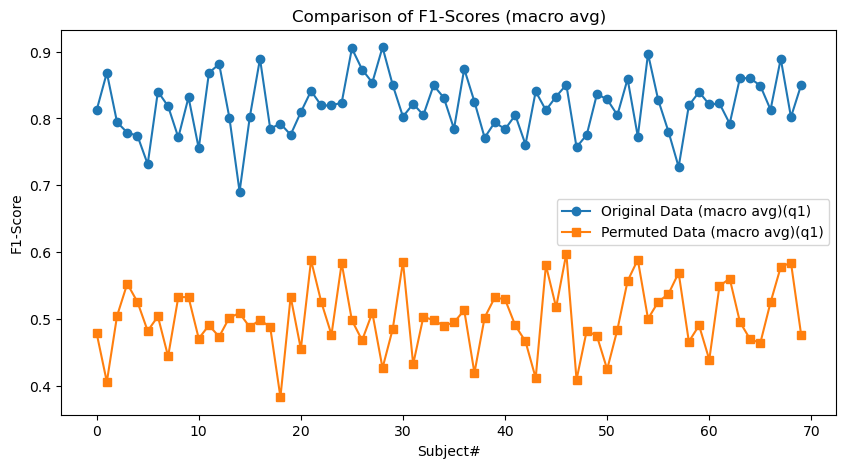

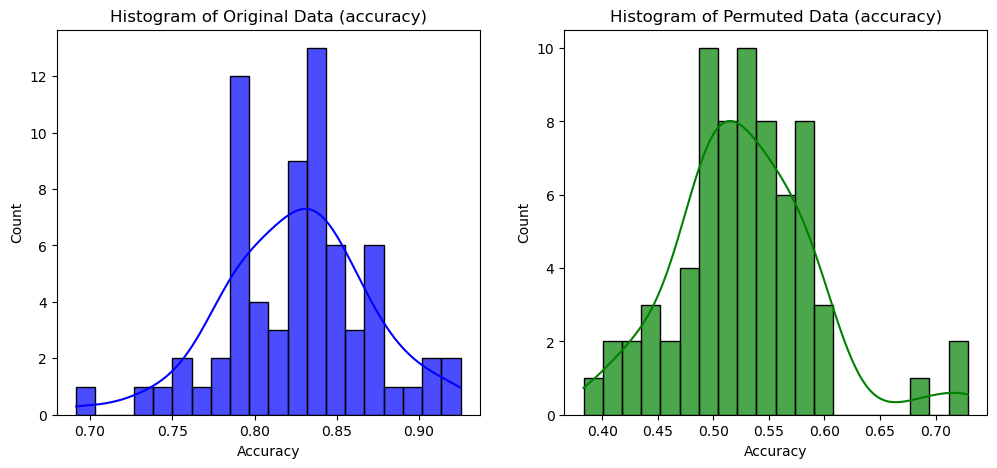

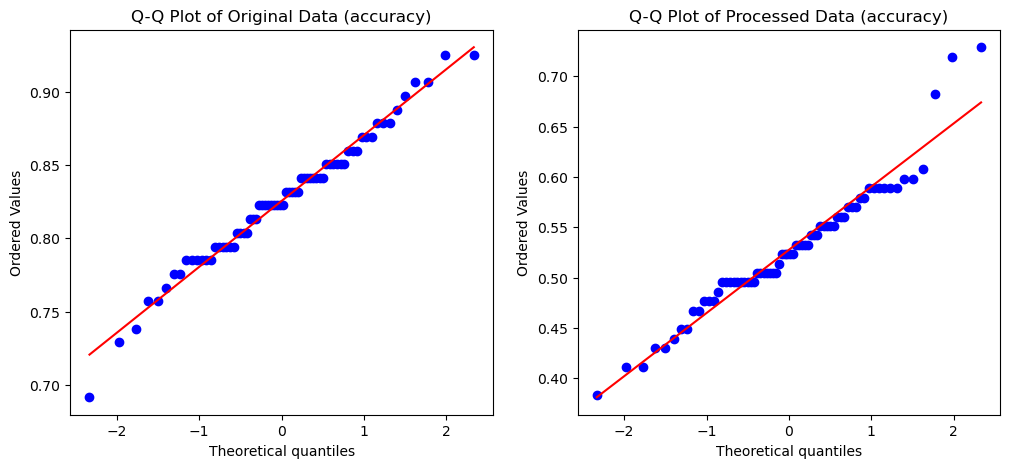

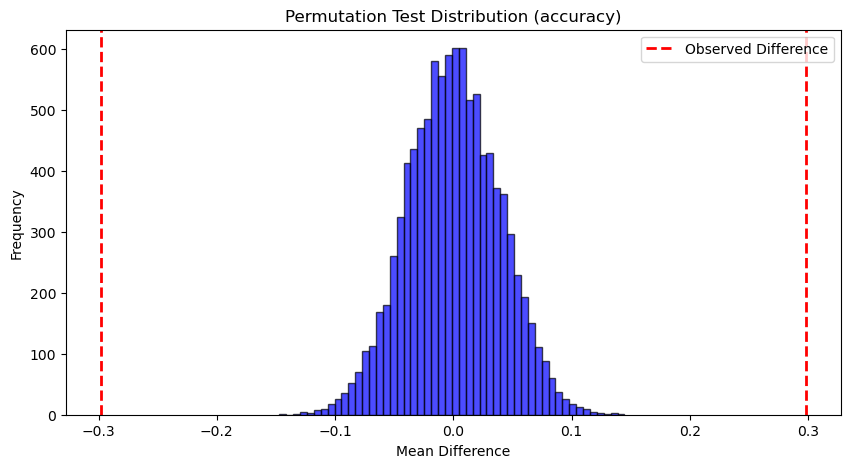

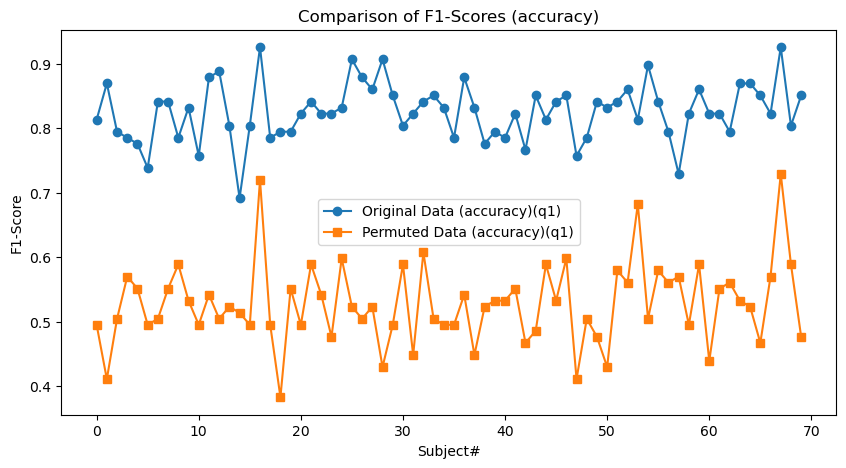

In [4]:
############ Quick t-test and permutation test
########### Q1 ###############
## Notes: no weird outliers in ratings like other conditions
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\test_metrics_q1_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q1_results_final\test_metrics_q1_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")
# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
if f1_col not in df1.columns or f1_col not in df2.columns or metric_col not in df1.columns or metric_col not in df2.columns:
    raise ValueError(f"Required columns '{f1_col}' or '{metric_col}' not found in one or both files.")

# Filter for macro avg
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

# Extract F1-Score data
f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

#### adding accuracy
# Filter accuracy from rows where Class == "0" (as string)
df1_acc = df1[df1[metric_col] == "0"].copy()
df2_acc = df2[df2[metric_col] == "0"].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)

# Ensure both datasets have the same length for paired test
if len(f1_scores_1) != len(f1_scores_2):
    raise ValueError("The two datasets must have the same number of observations for a paired test.")

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (macro avg):")
print(f1_scores_1.describe())
print("\nPermuted Data (macro avg):")
print(f1_scores_2.describe())
print("\nAccuracy (Class == 0) - Original:")
print(acc_scores_1.describe())
print("\nAccuracy (Class == 0) - Permuted:")
print(acc_scores_2.describe())

# Check assumption of normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk Test):")
print(f"Original Data: W={stat1:.4f}, p={p1:.4f}")
print(f"Permuted Data: W={stat2:.4f}, p={p2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

def cohens_d_paired(x, y):
    """Calculate Cohen's d for paired samples"""
    diff = np.array(x) - np.array(y)
    return np.mean(diff) / np.std(diff, ddof=1)
    
# Calculate Cohen's d
d_f1 = cohens_d_paired(f1_scores_1, f1_scores_2)
d_acc = cohens_d_paired(acc_scores_1, acc_scores_2)

# Print results
print(f"F1 Scores - paired t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}, Cohen's d: {d_f1:.3f}")
print(f"Accuracy - paired t-statistic: {t_acc:.3f}, p-value: {p_acc:.3f}, Cohen's d: {d_acc:.3f}")

# Save test results to a file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results for F1:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("The difference in F1-Scores (macro avg) is statistically significant.\n")
    else:
        f.write("No significant difference in F1-Scores (macro avg) between the two files.\n")
    f.write("Paired t-test results for accuracy:\n")
    f.write(f"T-statistic: {t_acc:.4f}\n")
    f.write(f"P-value: {p_acc:.4f}\n")
    if p_acc < 0.05:
        f.write("The difference in F1-Score for accuracy is statistically significant.\n")
    else:
        f.write("No significant difference in accuracy between the two files.\n")
        
# Permutation test
np.random.seed(42)  # For reproducibility
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)
observed_diff_acc = np.mean(acc_scores_1 - acc_scores_2)

# Generate permuted differences
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)
perm_diffs_acc = permute_test(acc_scores_1, acc_scores_2, num_permutations)

# Compute permutation p-value
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("\nPermutation Test Results for F1:")
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"Permutation P-value: {perm_p_value:.4f}")

perm_p_value_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(observed_diff_acc))
print("\nPermutation Test Results for Accuracy:")
print(f"Observed Mean Difference: {observed_diff_acc:.4f}")
print(f"Permutation P-value: {perm_p_value_acc:.4f}")

if perm_p_value < 0.05:
    print("The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).")
else:
    print("No significant difference in F1-Scores (macro avg) (Permutation Test).")

if perm_p_value_acc < 0.05:
    print("The difference in accuracy is statistically significant (Permutation Test).")
else:
    print("No significant difference in accuracy (Permutation Test).")

# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()

#################### Visualization for accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(acc_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (accuracy)")
plt.subplot(1, 2, 2)
sns.histplot(acc_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"acc_histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(acc_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (accuracy)")
plt.subplot(1, 2, 2)
stats.probplot(acc_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"accuracy_qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff_acc, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff_acc, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"accuracy_permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(acc_scores_1.values, label=f'Original Data (accuracy)({condition_name})', marker='o')
plt.plot(acc_scores_2.values, label=f'Permuted Data (accuracy)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"accuracy_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()



Participants with F1 = 1:
['corrected_32_processed_final', 'corrected_42_processed_final', 'corrected_39_processed_final', 'corrected_37_processed_final', 'corrected_26_processed_final', 'corrected_16_processed_final', 'corrected_63_processed_final']
Descriptive Statistics:
Original Data (macro avg):
count    62.000000
mean      0.827858
std       0.049935
min       0.690616
25%       0.796659
50%       0.828534
75%       0.855204
max       0.968050
Name: F1, dtype: float64

Permuted Data (macro avg):
count    62.000000
mean      0.497936
std       0.047245
min       0.390211
25%       0.463024
50%       0.500261
75%       0.525744
max       0.648851
Name: F1, dtype: float64

Accuracy - Original:
count    62.000000
mean      0.848960
std       0.058553
min       0.691589
25%       0.813084
50%       0.841121
75%       0.897196
max       0.990654
Name: Accuracy, dtype: float64

Accuracy - Permuted:
count    62.000000
mean      0.571450
std       0.099554
min       0.429907
25%       0.

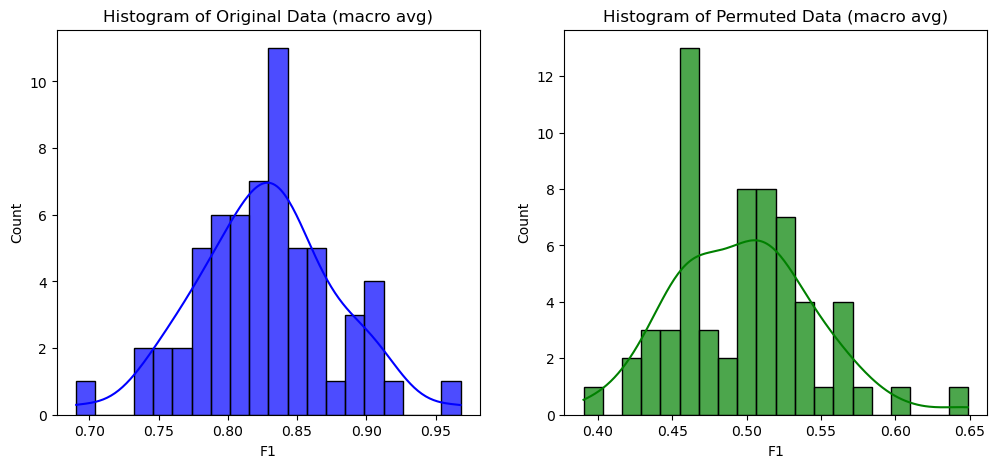

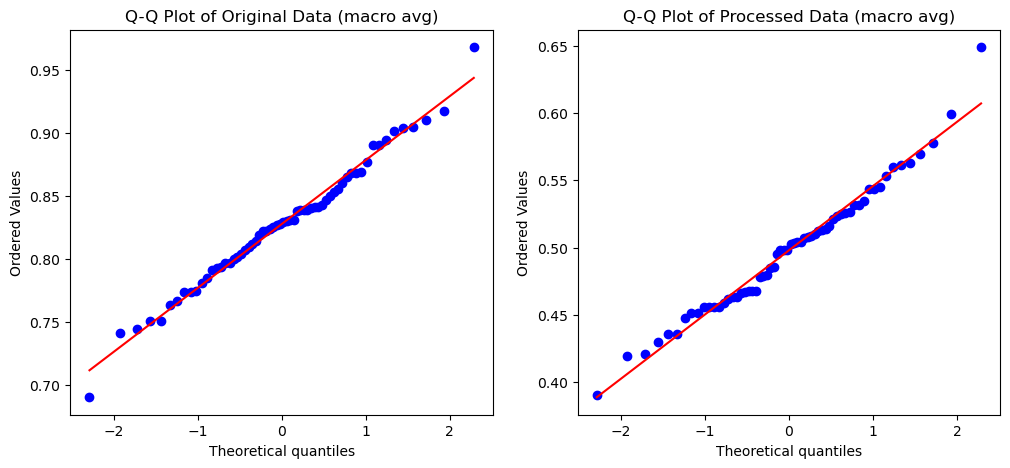

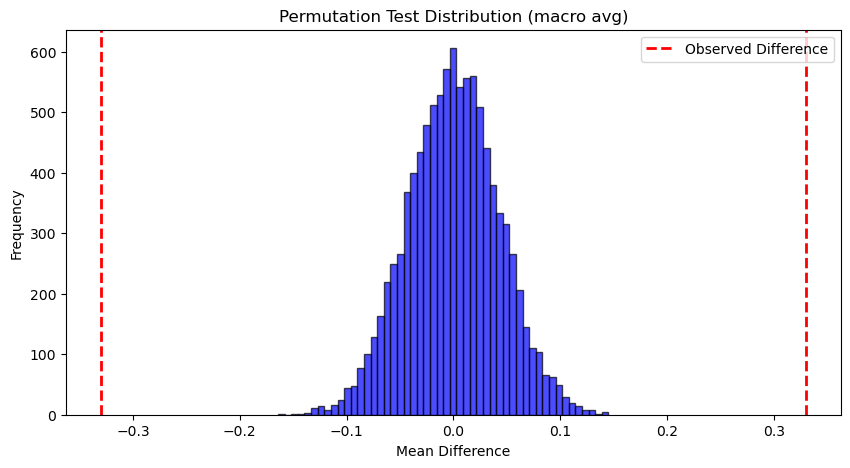

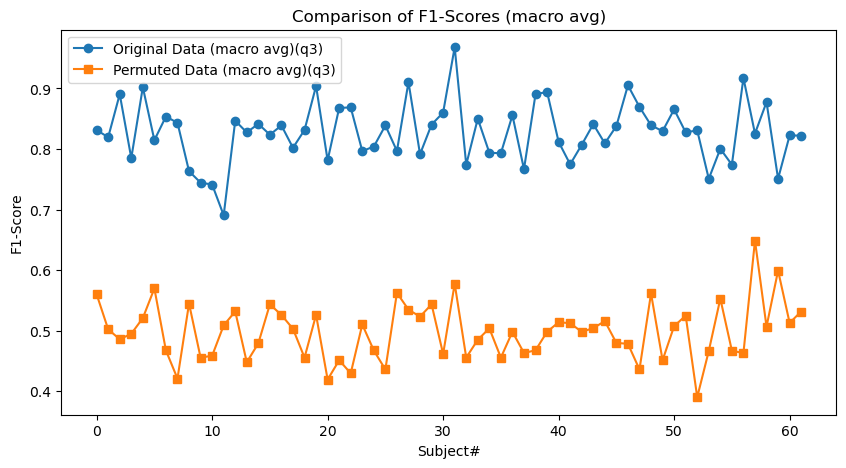

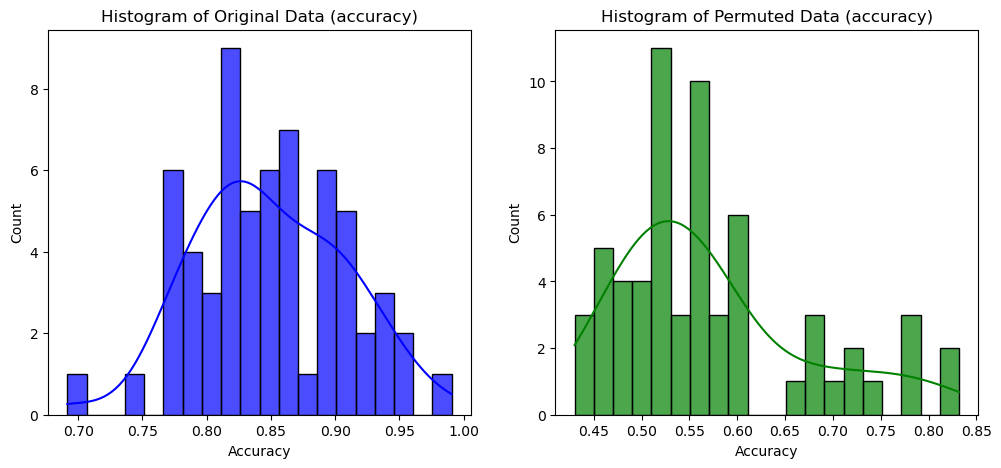

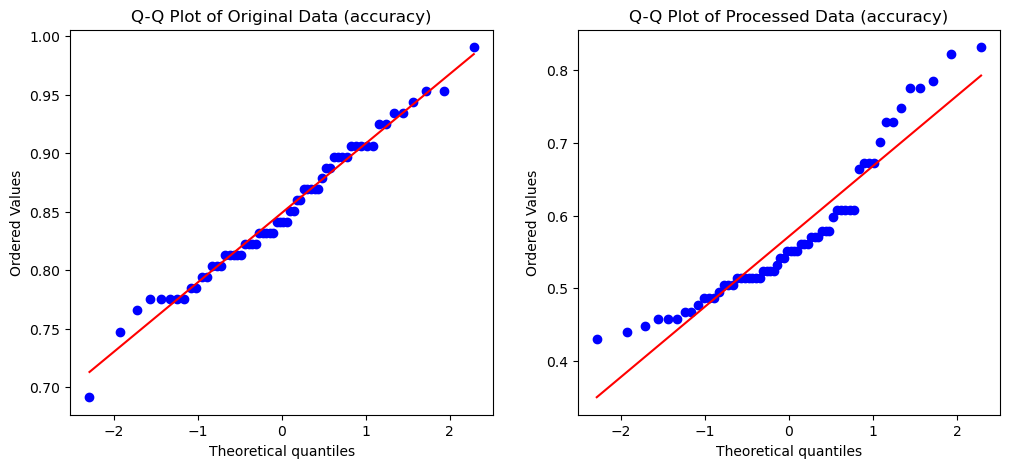

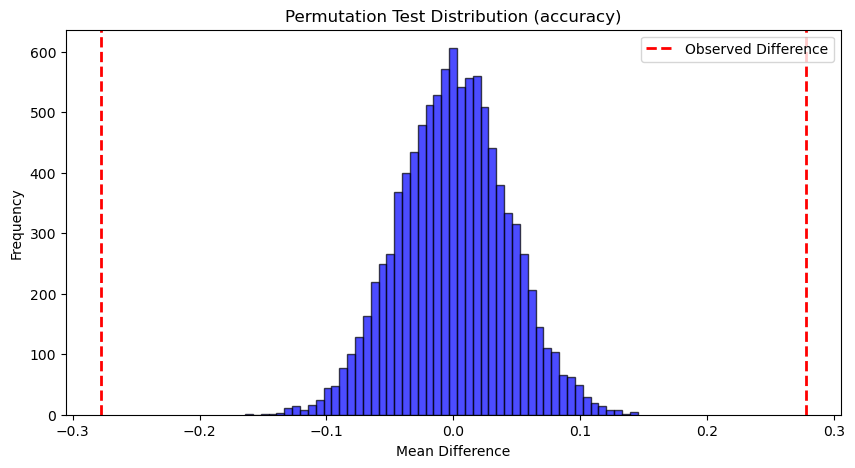

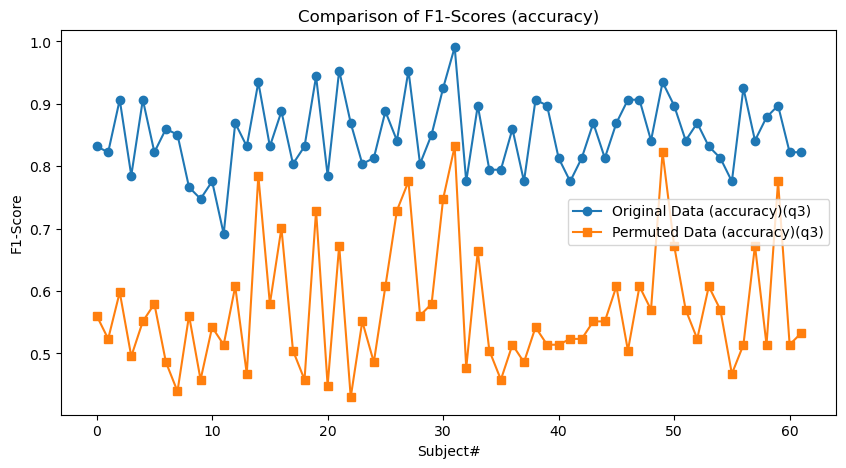

In [21]:
############ Quick t-test and permutation test
########### Q3,empathy ############
######## Notes on weird data: subjects had F1 of 1:63, 37, 42, 16, 32, 39, 26
#Participants with F1 = 1:
#[63(class0:3), 37(class1:6), 42(class0:7), 16(class0:2), 32(class1:3), 39(class1:3), 26(class1:5)]

import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\test_metrics_q3_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q3_results_final\test_metrics_q3_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")
# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
if f1_col not in df1.columns or f1_col not in df2.columns or metric_col not in df1.columns or metric_col not in df2.columns:
    raise ValueError(f"Required columns '{f1_col}' or '{metric_col}' not found in one or both files.")

# Filter for macro avg
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

# ====== NEW STEP: Find and remove participants with F1 == 1 ======
participants_with_f1_1 = df1_macro[df1_macro[f1_col] == 1]

if not participants_with_f1_1.empty:
    print("\nParticipants with F1 = 1:")
    print(participants_with_f1_1['Participant'].tolist())

    # Remove these participants
    subjects_to_remove = participants_with_f1_1['Participant'].tolist()
    df1_macro = df1_macro[~df1_macro['Participant'].isin(subjects_to_remove)].copy()
    df2_macro = df2_macro[~df2_macro['Participant'].isin(subjects_to_remove)].copy()
else:
    print("\nNo participants had F1 = 1.")

# Extract F1-Score data
f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# ====== ACCURACY ANALYSIS, filtered by same participants ======
# Filter accuracy from rows where Class == "0" or "1"
df1_acc = df1[df1[metric_col].isin(["0", "1"])].copy()
df2_acc = df2[df2[metric_col].isin(["0", "1"])].copy()

# Remove same participants from accuracy DataFrames
df1_acc = df1_acc[~df1_acc['Participant'].isin(subjects_to_remove)].copy()
df2_acc = df2_acc[~df2_acc['Participant'].isin(subjects_to_remove)].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)


# Ensure both datasets have the same length for paired test
if len(f1_scores_1) != len(f1_scores_2):
    raise ValueError("The two datasets must have the same number of observations for a paired test.")

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (macro avg):")
print(f1_scores_1.describe())
print("\nPermuted Data (macro avg):")
print(f1_scores_2.describe())
print("\nAccuracy - Original:")
print(acc_scores_1.describe())
print("\nAccuracy - Permuted:")
print(acc_scores_2.describe())

# Check assumption of normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk Test):")
print(f"Original Data: W={stat1:.4f}, p={p1:.4f}")
print(f"Permuted Data: W={stat2:.4f}, p={p2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

def cohens_d_paired(x, y):
    """Calculate Cohen's d for paired samples"""
    diff = np.array(x) - np.array(y)
    return np.mean(diff) / np.std(diff, ddof=1)
    
# Calculate Cohen's d
d_f1 = cohens_d_paired(f1_scores_1, f1_scores_2)
d_acc = cohens_d_paired(acc_scores_1, acc_scores_2)

# Print results
print(f"F1 Scores - paired t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}, Cohen's d: {d_f1:.3f}")
print(f"Accuracy - paired t-statistic: {t_acc:.3f}, p-value: {p_acc:.3f}, Cohen's d: {d_acc:.3f}")

# Print results
print("\nF1 Paired t-test results:")
print(f"F1 T-statistic: {t_stat:.4f}")
print(f"f1 P-value: {p_value:.4f}")
print("\nAccuracy Paired t-test results:")
print(f"Accuracy: T-statostic: {t_acc:.4f}")
print(f"Accuracy P-value: {p_acc:.4f}")

# Save test results to a file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results for F1:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("The difference in F1-Scores (macro avg) is statistically significant.\n")
    else:
        f.write("No significant difference in F1-Scores (macro avg) between the two files.\n")
    f.write("Paired t-test results for accuracy:\n")
    f.write(f"T-statistic: {t_acc:.4f}\n")
    f.write(f"P-value: {p_acc:.4f}\n")
    if p_acc < 0.05:
        f.write("The difference in F1-Score for accuracy is statistically significant.\n")
    else:
        f.write("No significant difference in accuracy between the two files.\n")
        
# Permutation test
np.random.seed(42)  # For reproducibility
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)
observed_diff_acc = np.mean(acc_scores_1 - acc_scores_2)

# Generate permuted differences
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)
perm_diffs_acc = permute_test(acc_scores_1, acc_scores_2, num_permutations)

# Compute permutation p-value
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("\nPermutation Test Results for F1:")
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"Permutation P-value: {perm_p_value:.4f}")

perm_p_value_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(observed_diff_acc))
print("\nPermutation Test Results for Accuracy:")
print(f"Observed Mean Difference: {observed_diff_acc:.4f}")
print(f"Permutation P-value: {perm_p_value_acc:.4f}")

if perm_p_value < 0.05:
    print("The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).")
else:
    print("No significant difference in F1-Scores (macro avg) (Permutation Test).")

if perm_p_value_acc < 0.05:
    print("The difference in accuracy is statistically significant (Permutation Test).")
else:
    print("No significant difference in accuracy (Permutation Test).")

# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()

#################### Visualization for accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(acc_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (accuracy)")
plt.subplot(1, 2, 2)
sns.histplot(acc_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"acc_histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(acc_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (accuracy)")
plt.subplot(1, 2, 2)
stats.probplot(acc_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"accuracy_qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff_acc, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff_acc, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"accuracy_permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(acc_scores_1.values, label=f'Original Data (accuracy)({condition_name})', marker='o')
plt.plot(acc_scores_2.values, label=f'Permuted Data (accuracy)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"accuracy_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()


Participants with F1 = 1:
['corrected_17_processed_final']
Descriptive Statistics:
Original Data (macro avg):
count    69.000000
mean      0.814064
std       0.044953
min       0.711965
25%       0.781696
50%       0.810787
75%       0.843223
max       0.923571
Name: F1, dtype: float64

Permuted Data (macro avg):
count    69.000000
mean      0.496496
std       0.046997
min       0.359958
25%       0.469489
50%       0.500308
75%       0.532343
max       0.580392
Name: F1, dtype: float64

Accuracy (Class == 0) - Original:
count    69.000000
mean      0.829473
std       0.050821
min       0.728972
25%       0.794393
50%       0.822430
75%       0.859813
max       0.981308
Name: Accuracy, dtype: float64

Accuracy (Class == 0) - Permuted:
count    69.000000
mean      0.544630
std       0.090864
min       0.364486
25%       0.495327
50%       0.532710
75%       0.560748
max       0.850467
Name: Accuracy, dtype: float64

Normality Test (Shapiro-Wilk Test):
Original Data: W=0.9840, p=0.5223


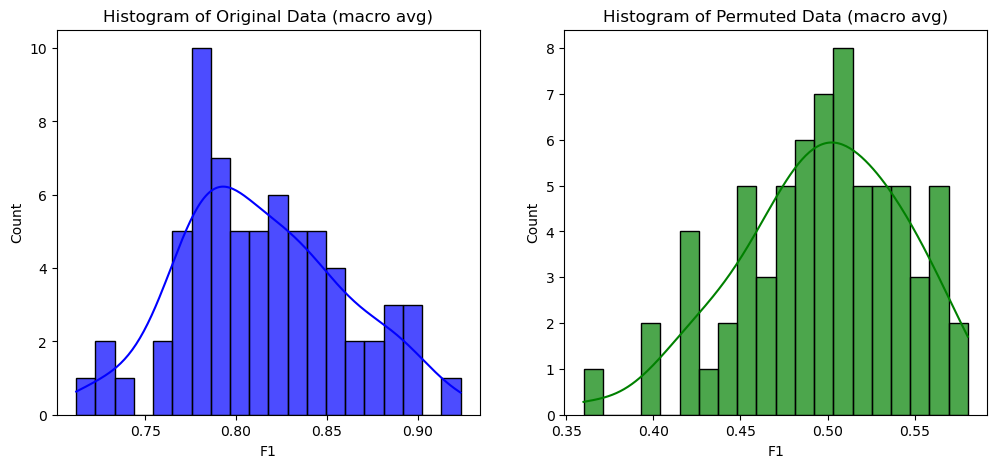

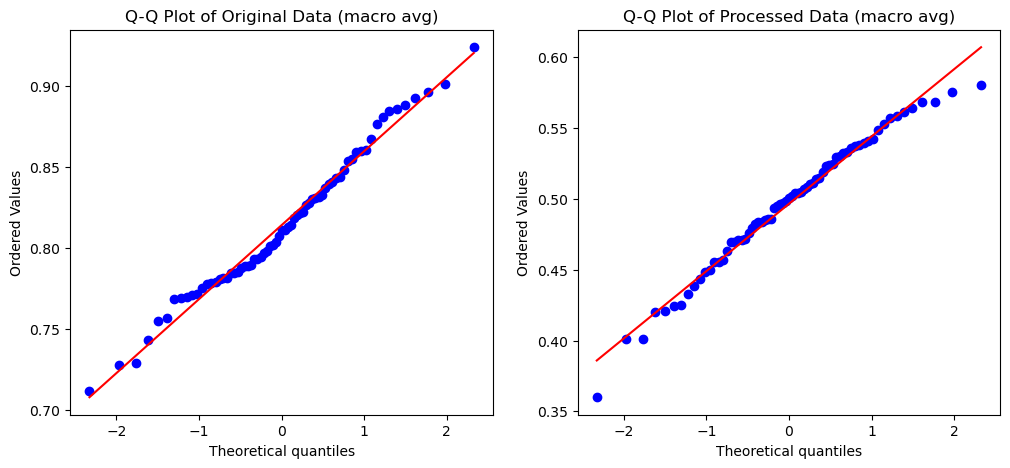

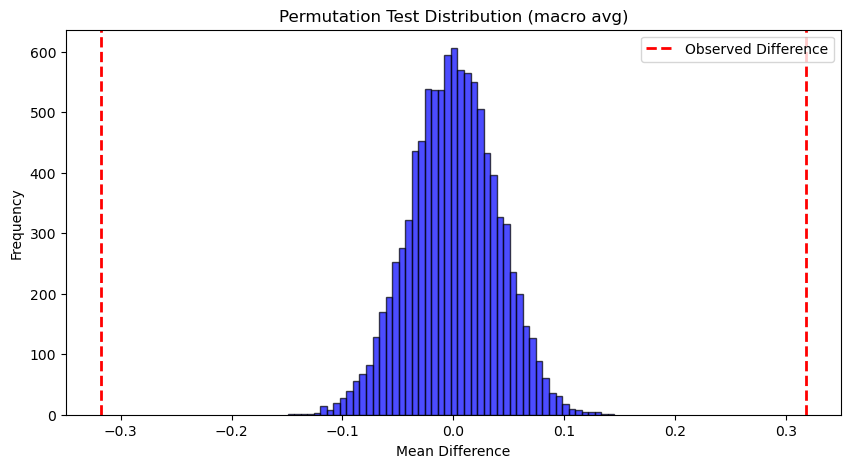

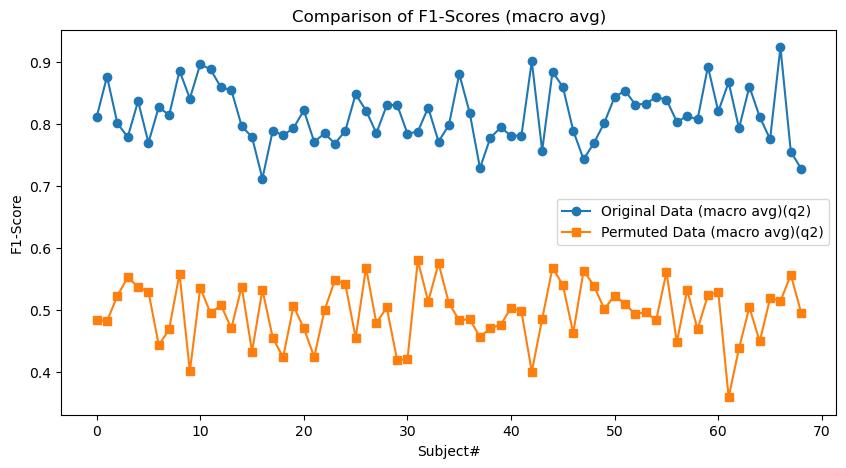

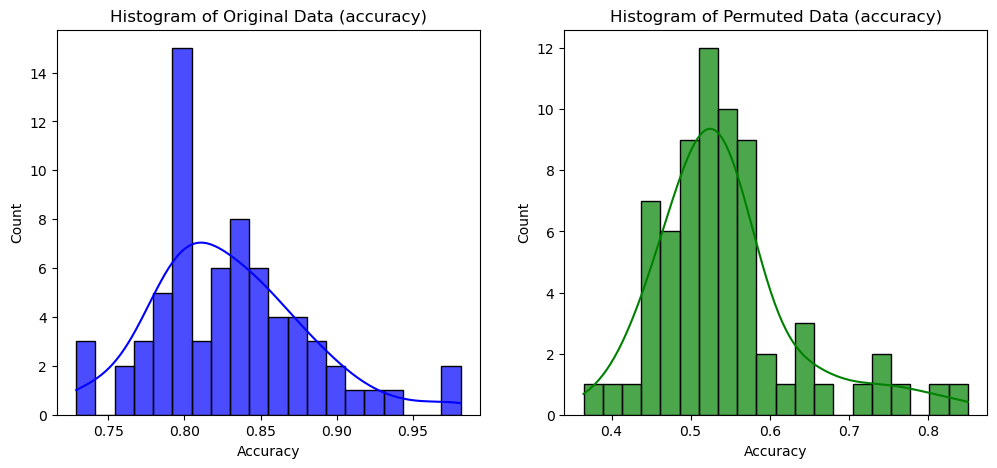

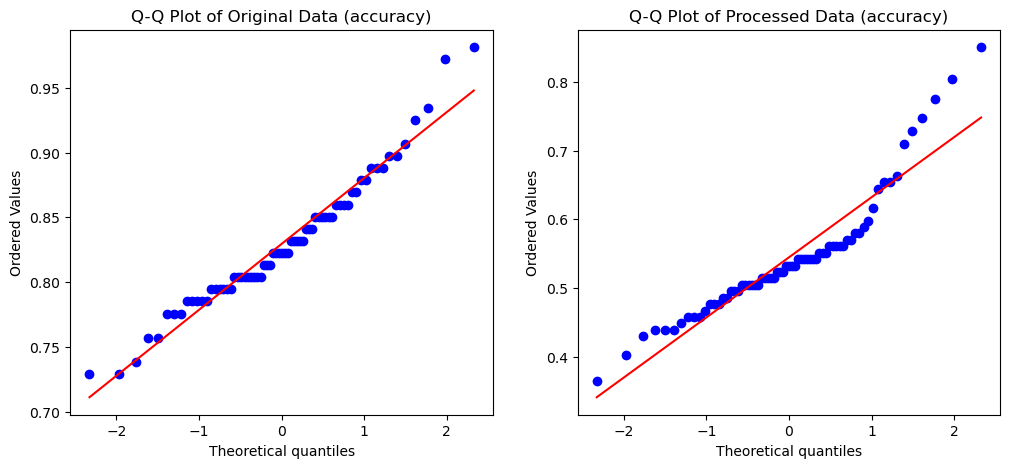

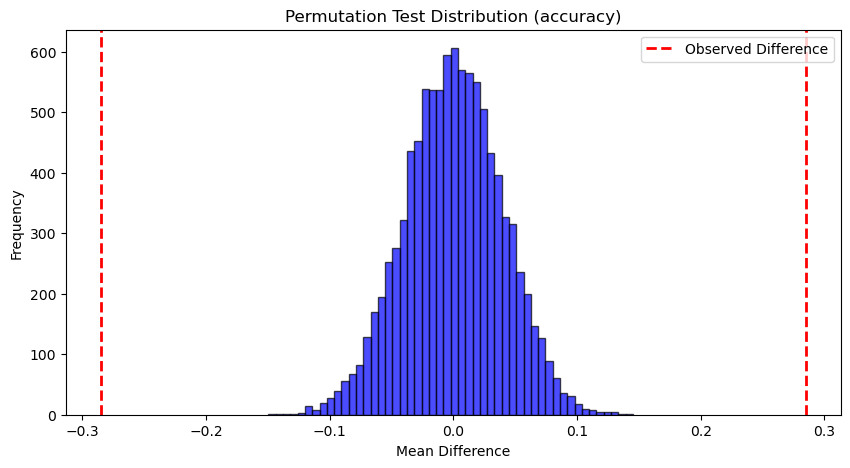

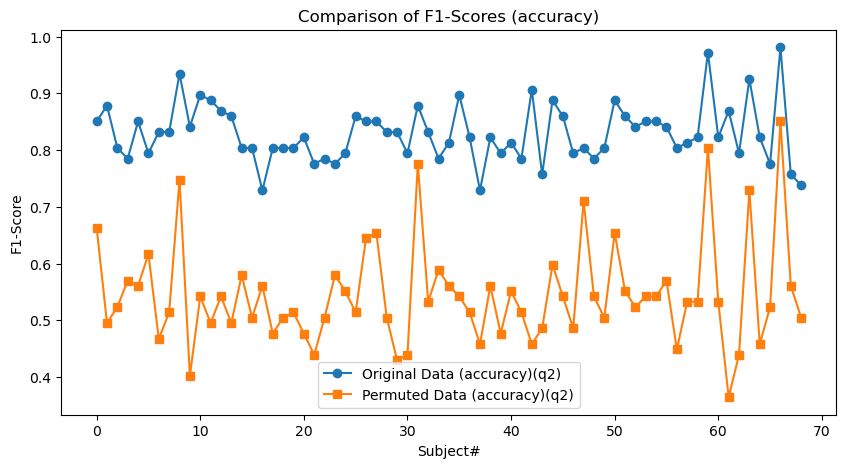

In [12]:
############ Quick t-test and permutation test
########### Q2 ###########
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\test_metrics_q2_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q2_results_final\test_metrics_q2_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")
# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
if f1_col not in df1.columns or f1_col not in df2.columns or metric_col not in df1.columns or metric_col not in df2.columns:
    raise ValueError(f"Required columns '{f1_col}' or '{metric_col}' not found in one or both files.")

# Filter for macro avg
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

# ====== NEW STEP: Find and remove participants with F1 == 1 ======
participants_with_f1_1 = df1_macro[df1_macro[f1_col] == 1]

if not participants_with_f1_1.empty:
    print("\nParticipants with F1 = 1:")
    print(participants_with_f1_1['Participant'].tolist())

    # Remove these participants
    subjects_to_remove = participants_with_f1_1['Participant'].tolist()
    df1_macro = df1_macro[~df1_macro['Participant'].isin(subjects_to_remove)].copy()
    df2_macro = df2_macro[~df2_macro['Participant'].isin(subjects_to_remove)].copy()
else:
    print("\nNo participants had F1 = 1.")

# Extract F1-Score data
f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# ====== ACCURACY ANALYSIS, filtered by same participants ======
# Filter accuracy from rows where Class == "0" or "1"
df1_acc = df1[df1[metric_col].isin(["0", "1"])].copy()
df2_acc = df2[df2[metric_col].isin(["0", "1"])].copy()

# Remove same participants from accuracy DataFrames
df1_acc = df1_acc[~df1_acc['Participant'].isin(subjects_to_remove)].copy()
df2_acc = df2_acc[~df2_acc['Participant'].isin(subjects_to_remove)].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)

# Ensure both datasets have the same length for paired test
if len(f1_scores_1) != len(f1_scores_2):
    raise ValueError("The two datasets must have the same number of observations for a paired test.")

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (macro avg):")
print(f1_scores_1.describe())
print("\nPermuted Data (macro avg):")
print(f1_scores_2.describe())
print("\nAccuracy (Class == 0) - Original:")
print(acc_scores_1.describe())
print("\nAccuracy (Class == 0) - Permuted:")
print(acc_scores_2.describe())

# Check assumption of normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk Test):")
print(f"Original Data: W={stat1:.4f}, p={p1:.4f}")
print(f"Permuted Data: W={stat2:.4f}, p={p2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

def cohens_d_paired(x, y):
    """Calculate Cohen's d for paired samples"""
    diff = np.array(x) - np.array(y)
    return np.mean(diff) / np.std(diff, ddof=1)
    
# Calculate Cohen's d
d_f1 = cohens_d_paired(f1_scores_1, f1_scores_2)
d_acc = cohens_d_paired(acc_scores_1, acc_scores_2)

# Print results
print(f"F1 Scores - paired t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}, Cohen's d: {d_f1:.3f}")
print(f"Accuracy - paired t-statistic: {t_acc:.3f}, p-value: {p_acc:.3f}, Cohen's d: {d_acc:.3f}")

# Print results
print("\nF1 Paired t-test results:")
print(f"F1 T-statistic: {t_stat:.4f}")
print(f"f1 P-value: {p_value:.4f}")
print("\nAccuracy Paired t-test results:")
print(f"Accuracy: T-statostic: {t_acc:.4f}")
print(f"Accuracy P-value: {p_acc:.4f}")

# Save test results to a file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results for F1:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("The difference in F1-Scores (macro avg) is statistically significant.\n")
    else:
        f.write("No significant difference in F1-Scores (macro avg) between the two files.\n")
    f.write("Paired t-test results for accuracy:\n")
    f.write(f"T-statistic: {t_acc:.4f}\n")
    f.write(f"P-value: {p_acc:.4f}\n")
    if p_acc < 0.05:
        f.write("The difference in F1-Score for accuracy is statistically significant.\n")
    else:
        f.write("No significant difference in accuracy between the two files.\n")
        
# Permutation test
np.random.seed(42)  # For reproducibility
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)
observed_diff_acc = np.mean(acc_scores_1 - acc_scores_2)

# Generate permuted differences
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)
perm_diffs_acc = permute_test(acc_scores_1, acc_scores_2, num_permutations)

# Compute permutation p-value
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("\nPermutation Test Results for F1:")
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"Permutation P-value: {perm_p_value:.4f}")

perm_p_value_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(observed_diff_acc))
print("\nPermutation Test Results for Accuracy:")
print(f"Observed Mean Difference: {observed_diff_acc:.4f}")
print(f"Permutation P-value: {perm_p_value_acc:.4f}")

if perm_p_value < 0.05:
    print("The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).")
else:
    print("No significant difference in F1-Scores (macro avg) (Permutation Test).")

if perm_p_value_acc < 0.05:
    print("The difference in accuracy is statistically significant (Permutation Test).")
else:
    print("No significant difference in accuracy (Permutation Test).")

# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()

#################### Visualization for accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(acc_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (accuracy)")
plt.subplot(1, 2, 2)
sns.histplot(acc_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"acc_histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(acc_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (accuracy)")
plt.subplot(1, 2, 2)
stats.probplot(acc_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"accuracy_qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff_acc, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff_acc, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"accuracy_permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(acc_scores_1.values, label=f'Original Data (accuracy)({condition_name})', marker='o')
plt.plot(acc_scores_2.values, label=f'Permuted Data (accuracy)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"accuracy_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()


Descriptive Statistics:
Original Data (macro avg):
count    72.000000
mean      0.813626
std       0.049035
min       0.691198
25%       0.790023
50%       0.818298
75%       0.847470
max       0.923297
Name: F1, dtype: float64

Permuted Data (macro avg):
count    72.000000
mean      0.496526
std       0.039707
min       0.399706
25%       0.468794
50%       0.495729
75%       0.522765
max       0.640672
Name: F1, dtype: float64

Accuracy (Class == 0) - Original:
count    71.000000
mean      0.817560
std       0.047651
min       0.700935
25%       0.794393
50%       0.822430
75%       0.850467
max       0.925234
Name: Accuracy, dtype: float64

Accuracy (Class == 0) - Permuted:
count    71.000000
mean      0.514150
std       0.039287
min       0.429907
25%       0.485981
50%       0.514019
75%       0.542056
max       0.663551
Name: Accuracy, dtype: float64

Normality Test (Shapiro-Wilk Test):
Original Data: W=0.9844, p=0.5144
Permuted Data: W=0.9749, p=0.1597
Acc Original: W=0.9866, p=

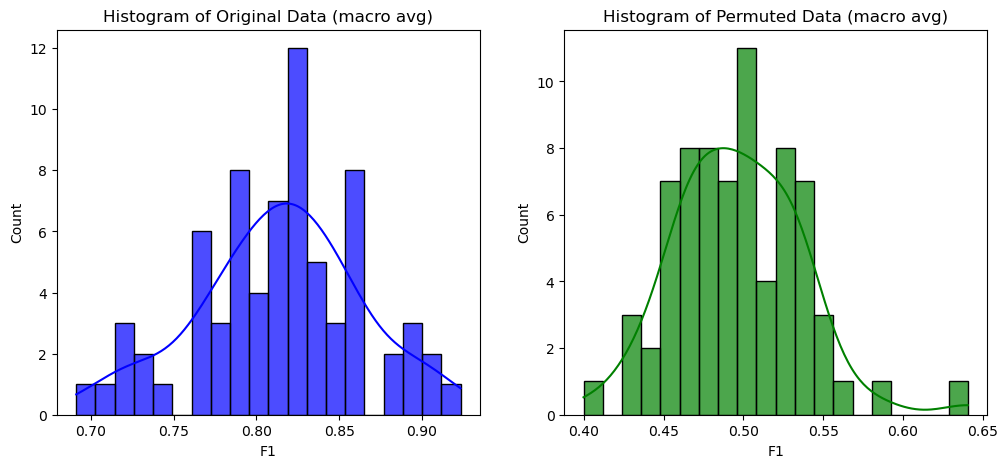

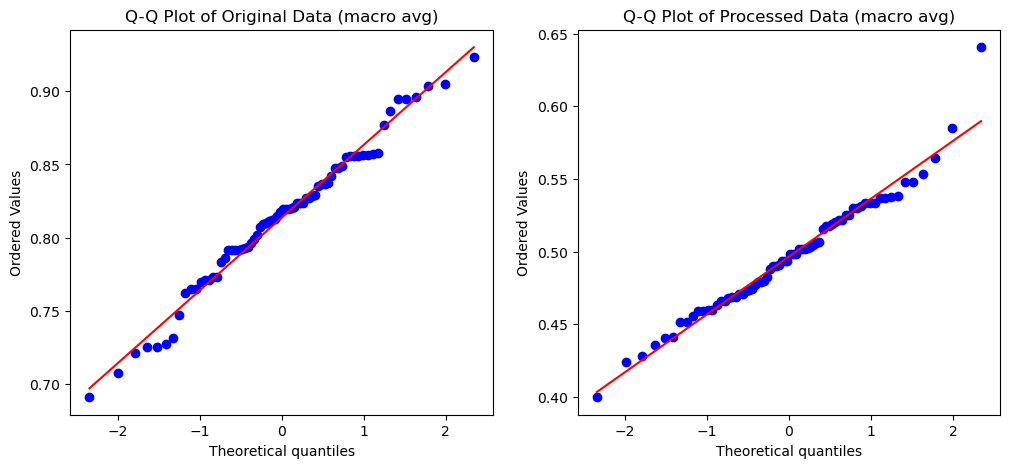

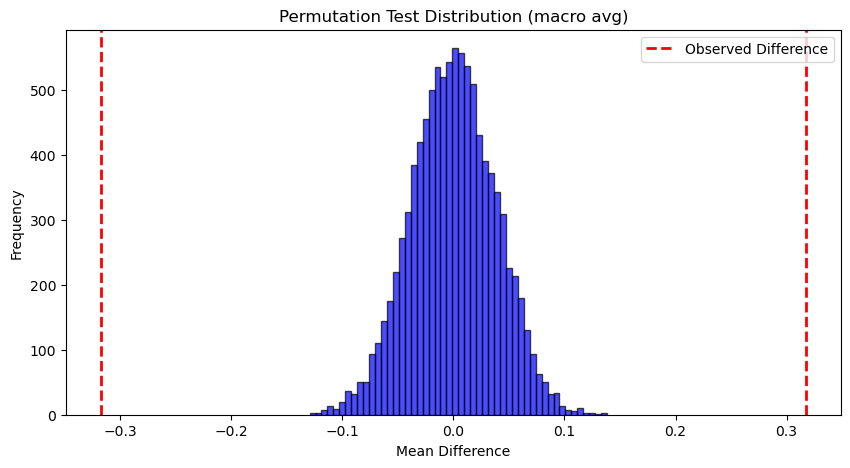

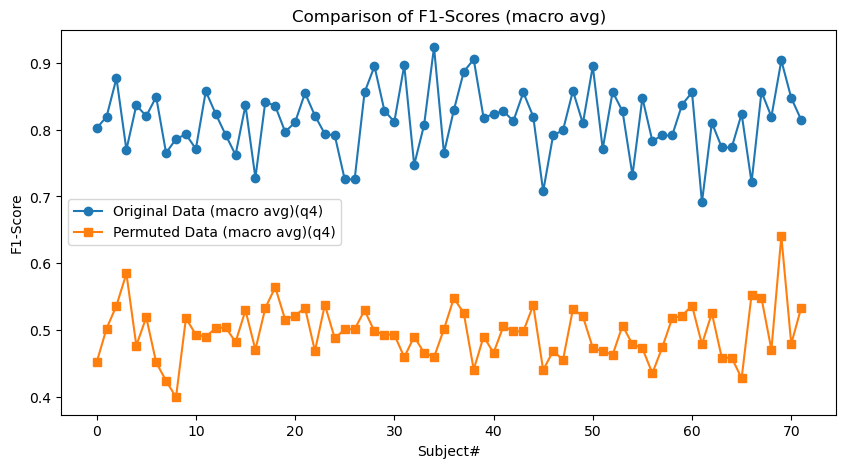

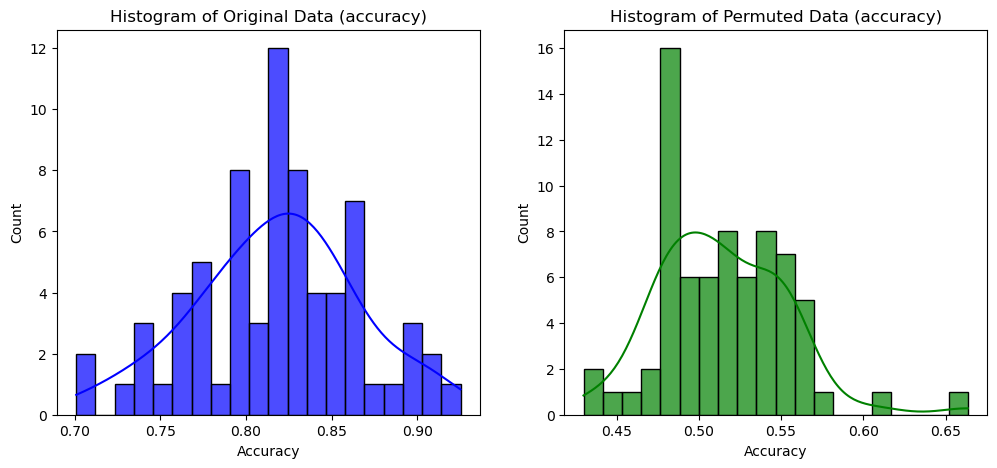

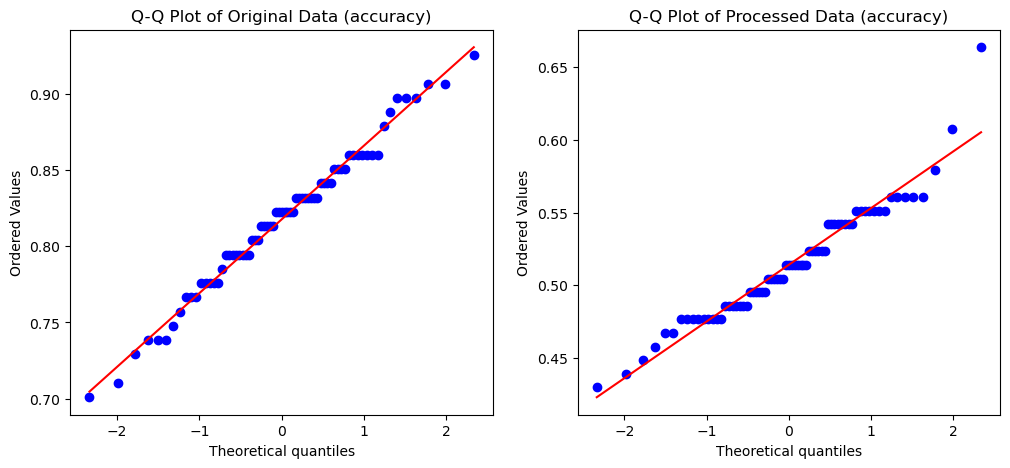

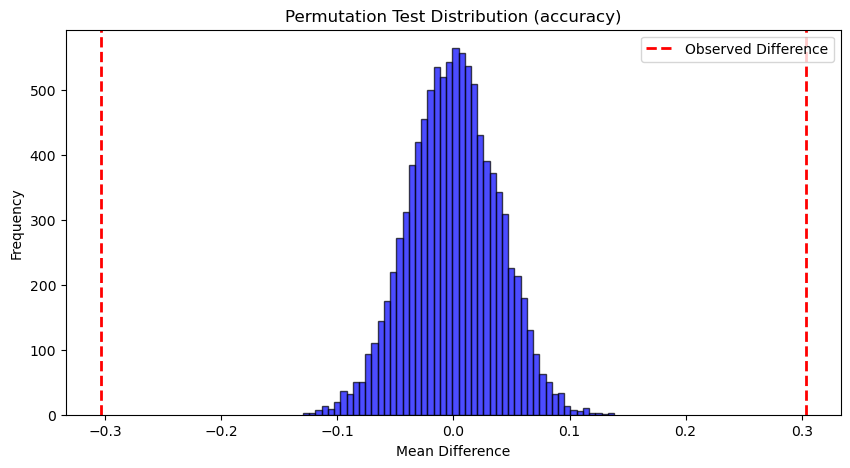

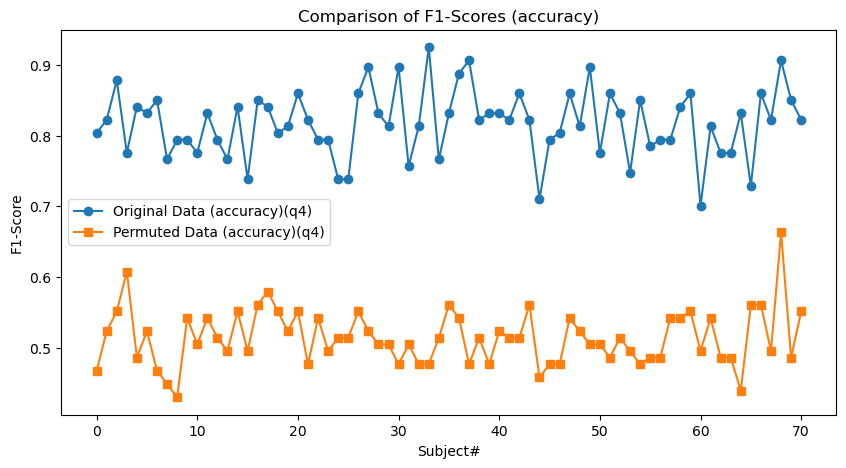

In [16]:
############ Quick t-test and permutation test
########### Q4 ##########
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths, change q1,q2,q3,q4 based on the predicted variable
file_original = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\test_metrics_q4_y_original.csv"
file_permuted= r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results\q4_results_final\test_metrics_q4_y_permutation.csv"
output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\Results"

# Extract condition name from file_original
condition_name = None
filename = os.path.basename(file_original)
if "q" in filename:
    parts = filename.split("_")
    for part in parts:
        if part.startswith("q") and part[1:].isdigit():
            condition_name = part
            break

if not condition_name:
    raise ValueError("Could not extract condition name from filename.")
# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df1 = pd.read_csv(file_original)
df2 = pd.read_csv(file_permuted)

# Ensure required columns exist
f1_col = "F1"
acc_col = "Accuracy"
metric_col = "Class"
if f1_col not in df1.columns or f1_col not in df2.columns or metric_col not in df1.columns or metric_col not in df2.columns:
    raise ValueError(f"Required columns '{f1_col}' or '{metric_col}' not found in one or both files.")

# Filter for macro avg
df1_macro = df1[df1[metric_col] == "macro avg"]
df2_macro = df2[df2[metric_col] == "macro avg"]

# Extract F1-Score data
f1_scores_1 = df1_macro[f1_col].dropna()
f1_scores_2 = df2_macro[f1_col].dropna()

# ====== ACCURACY ANALYSIS, filtered by same participants ======
# Filter accuracy from rows where Class == "0" or "1"
df1_acc = df1[df1[metric_col].isin(["0", "1"])].copy()
df2_acc = df2[df2[metric_col].isin(["0", "1"])].copy()

# Remove same participants from accuracy DataFrames
df1_acc = df1_acc[~df1_acc['Participant'].isin(subjects_to_remove)].copy()
df2_acc = df2_acc[~df2_acc['Participant'].isin(subjects_to_remove)].copy()

# Extract Accuracy values and reset index
acc_scores_1 = df1_acc[acc_col].dropna().reset_index(drop=True)
acc_scores_2 = df2_acc[acc_col].dropna().reset_index(drop=True)

# Ensure both datasets have the same length for paired test
if len(f1_scores_1) != len(f1_scores_2):
    raise ValueError("The two datasets must have the same number of observations for a paired test.")

# Descriptive statistics
print("Descriptive Statistics:")
print("Original Data (macro avg):")
print(f1_scores_1.describe())
print("\nPermuted Data (macro avg):")
print(f1_scores_2.describe())
print("\nAccuracy (Class == 0) - Original:")
print(acc_scores_1.describe())
print("\nAccuracy (Class == 0) - Permuted:")
print(acc_scores_2.describe())

# Check assumption of normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(f1_scores_1)
stat2, p2 = stats.shapiro(f1_scores_2)
stat_acc_1, p_acc_1 = stats.shapiro(acc_scores_1)
stat_acc_2, p_acc_2 = stats.shapiro(acc_scores_2)
print("\nNormality Test (Shapiro-Wilk Test):")
print(f"Original Data: W={stat1:.4f}, p={p1:.4f}")
print(f"Permuted Data: W={stat2:.4f}, p={p2:.4f}")
print(f"Acc Original: W={stat_acc_1:.4f}, p={p_acc_1:.4f}")
print(f"Acc Permuted: W={stat_acc_2:.4f}, p={p_acc_2:.4f}")

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(f1_scores_1, f1_scores_2)
t_acc, p_acc = stats.ttest_rel(acc_scores_1, acc_scores_2)

def cohens_d_paired(x, y):
    """Calculate Cohen's d for paired samples"""
    diff = np.array(x) - np.array(y)
    return np.mean(diff) / np.std(diff, ddof=1)
    
# Calculate Cohen's d
d_f1 = cohens_d_paired(f1_scores_1, f1_scores_2)
d_acc = cohens_d_paired(acc_scores_1, acc_scores_2)

# Print results
print(f"F1 Scores - paired t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}, Cohen's d: {d_f1:.3f}")
print(f"Accuracy - paired t-statistic: {t_acc:.3f}, p-value: {p_acc:.3f}, Cohen's d: {d_acc:.3f}")

# Print results
print("\nF1 Paired t-test results:")
print(f"F1 T-statistic: {t_stat:.4f}")
print(f"f1 P-value: {p_value:.4f}")
print("\nAccuracy Paired t-test results:")
print(f"Accuracy: T-statostic: {t_acc:.4f}")
print(f"Accuracy P-value: {p_acc:.4f}")

# Save test results to a file
output_file = os.path.join(output_dir, f"test_results_{condition_name}.txt")
with open(output_file, "w") as f:
    f.write("Paired t-test results for F1:\n")
    f.write(f"T-statistic: {t_stat:.4f}\n")
    f.write(f"P-value: {p_value:.4f}\n")
    if p_value < 0.05:
        f.write("The difference in F1-Scores (macro avg) is statistically significant.\n")
    else:
        f.write("No significant difference in F1-Scores (macro avg) between the two files.\n")
    f.write("Paired t-test results for accuracy:\n")
    f.write(f"T-statistic: {t_acc:.4f}\n")
    f.write(f"P-value: {p_acc:.4f}\n")
    if p_acc < 0.05:
        f.write("The difference in F1-Score for accuracy is statistically significant.\n")
    else:
        f.write("No significant difference in accuracy between the two files.\n")
        
# Permutation test
np.random.seed(42)  # For reproducibility
num_permutations = 10000
observed_diff = np.mean(f1_scores_1 - f1_scores_2)
observed_diff_acc = np.mean(acc_scores_1 - acc_scores_2)

# Generate permuted differences
def permute_test(x, y, num_permutations=10000):
    diff_distribution = []
    for _ in range(num_permutations):
        signs = np.random.choice([-1, 1], size=len(x))
        perm_diff = np.mean(signs * (x - y))
        diff_distribution.append(perm_diff)
    return np.array(diff_distribution)

perm_diffs = permute_test(f1_scores_1, f1_scores_2, num_permutations)
perm_diffs_acc = permute_test(acc_scores_1, acc_scores_2, num_permutations)

# Compute permutation p-value
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print("\nPermutation Test Results for F1:")
print(f"Observed Mean Difference: {observed_diff:.4f}")
print(f"Permutation P-value: {perm_p_value:.4f}")

perm_p_value_acc = np.mean(np.abs(perm_diffs_acc) >= np.abs(observed_diff_acc))
print("\nPermutation Test Results for Accuracy:")
print(f"Observed Mean Difference: {observed_diff_acc:.4f}")
print(f"Permutation P-value: {perm_p_value_acc:.4f}")

if perm_p_value < 0.05:
    print("The difference in F1-Scores (macro avg) is statistically significant (Permutation Test).")
else:
    print("No significant difference in F1-Scores (macro avg) (Permutation Test).")

if perm_p_value_acc < 0.05:
    print("The difference in accuracy is statistically significant (Permutation Test).")
else:
    print("No significant difference in accuracy (Permutation Test).")

# Check normality using histograms and Q-Q plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(f1_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (macro avg)")
plt.subplot(1, 2, 2)
sns.histplot(f1_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(f1_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (macro avg)")
plt.subplot(1, 2, 2)
stats.probplot(f1_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (macro avg)")
plt.savefig(os.path.join(output_dir, f"qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(f1_scores_1.values, label=f'Original Data (macro avg)({condition_name})', marker='o')
plt.plot(f1_scores_2.values, label=f'Permuted Data (macro avg)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (macro avg)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"f1_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()

#################### Visualization for accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(acc_scores_1, kde=True, bins=20, color='blue', alpha=0.7)
plt.title("Histogram of Original Data (accuracy)")
plt.subplot(1, 2, 2)
sns.histplot(acc_scores_2, kde=True, bins=20, color='green', alpha=0.7)
plt.title("Histogram of Permuted Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"acc_histograms_{condition_name}.png"))  # Save histogram image
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(acc_scores_1, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Data (accuracy)")
plt.subplot(1, 2, 2)
stats.probplot(acc_scores_2, dist="norm", plot=plt)
plt.title("Q-Q Plot of Processed Data (accuracy)")
plt.savefig(os.path.join(output_dir, f"accuracy_qq_plots_{condition_name}.png"))  # Save Q-Q plot image
plt.show()

# Visualization of permutation distribution
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(observed_diff_acc, color='red', linestyle='dashed', linewidth=2, label='Observed Difference')
plt.axvline(-observed_diff_acc, color='red', linestyle='dashed', linewidth=2)
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.title('Permutation Test Distribution (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"accuracy_permutation_test_distribution_macro_avg_{condition_name}.png"))  # Save permutation test distribution image
plt.show()

# Visualization of F1-Score trends
plt.figure(figsize=(10, 5))
plt.plot(acc_scores_1.values, label=f'Original Data (accuracy)({condition_name})', marker='o')
plt.plot(acc_scores_2.values, label=f'Permuted Data (accuracy)({condition_name})', marker='s')
plt.xlabel('Subject#')
plt.ylabel('F1-Score')
plt.title('Comparison of F1-Scores (accuracy)')
plt.legend()
plt.savefig(os.path.join(output_dir, f"accuracy_score_comparison_macro_avg_{condition_name}.png"))  # Save F1-Score comparison image
plt.show()
